# Notes

In [ ]:
# Lower body
    # temporal 
        # every temporal parameter in seconds (later, apart from stride time every other thing should also be calcualted as % of stride time)
        # round temporal parameters to 3 digits
        # double support time has to be rewieved (2 stages for each cycle)

    # spatial
        # every spacial parameter in meters (round to 3 digits)
        # + foot progression angle [deg] (toe in / toe out in gaitrite, only contralateral can be calculated for each gait cycle)
            # at the end it has to be per side
        # foot height during swing (no precise def yet)
        
        # Rotations
        # possibly in 3D, joint/pateient centered coord system
        # ankle angle [deg]
        # knee angle [deg]
        # hip [deg] 

# Upper body
    # spatial
        # trunk ROM 3D [deg] (torsion included)
        # head ROM 3D [deg] (torsion included)
        # arm ROM [deg] in 2 planes (plane of progression, vertical plane tbd)
        # wrist angle [deg] 3D


# a class for every gait parameter
   

# first publication 
    # knee rom 
    # arm swing
    # kinect vs stereo 
    # stat: ICC3 in pingiun table (3rd options)

# Imports

In [1]:
## conda env: stereo_vision
import os
import cv2
import glob
import numpy as np
from rtmlib import draw_skeleton, draw_bbox
from Util.util import *
from Util.calibration_util import *
from Util.gait_util import *
from Util.statistics_util import *
import time
import json
from IPython.display import display, clear_output

import pyzed.sl as sl
import matplotlib.pyplot as plt # TODO: get the 5.11 SDK working

# load model info (config, input size, etc)
with open('./Util/2d_model/models.json') as f:
    models = json.load(f)

# load static properties for gait analysis
with open("./Util/gait_analysis_properties.json", "r") as json_file:
    gait_analysis_properties = json.load(json_file)
    stereo_properties = gait_analysis_properties["stereo"]
    qualisys_properties = gait_analysis_properties["qualisys"]

%matplotlib ipympl

# get ZED SDK verison
print(f"ZED SDK: {sl.Camera.get_sdk_version()}")

ZED SDK: 5.0.3


In [2]:
participant = "mate_unger"
paradigm = "normal_walking"

In [ ]:
# from export_stereo_video import *

export_svo_avi(
    input_path="D:\\mwuehr\\stereolabs_valdiation\\data\\vasil_derventliev\\stereolabs\\E4F91ED1-FD25-4A0C-BD82-11BC643510E8\\43916681.svo2",
    output_path="D:\\mwuehr\\stereolabs_valdiation\\data\\vasil_derventliev\\stereolabs\\E4F91ED1-FD25-4A0C-BD82-11BC643510E8\\43916681.avi"
)

# 2D Keypoints

## Model setup

In [ ]:
device = "cuda"  # cpu, cuda, mps
backend = "onnxruntime"  # opencv, onnxruntime, openvino
detector_name = 'YOLOX_nano' # 'YOLOX_l_COCO','YOLOX_nano','YOLOX_tiny','YOLOX_s','YOLOX_m','YOLOX_l','YOLOX_x'
pose_name = 'RTMPose_x' # (26) 'RTMPose_t', 'RTMPose_s', 'RTMPose_m', 'RTMPose_l', 'RTMPose_m2', 'RTMPose_l2', 'RTMPose_x', (133) 'RTMW_l', 'RTMW_x'
kpt_labels = models['pose_models']["26"]["kpt_labels"]

custom = Custom(det_class='YOLOX', #'RTMDet',
                det=models['detectors'][detector_name]['path'],
                det_input_size=models['detectors'][detector_name]['input_size'],
                pose_class='RTMPose',
                pose=models['pose_models']["26"]["models"][pose_name]['path'],
                pose_input_size=models['pose_models']["26"]["models"][pose_name]['input_size'],
                backend=backend,
                device=device) 

#TODO: fix CUDA not being used

## 2D inference

In [ ]:
input_folder = f".\\stereo_videos\\validation_test\\{participant}\\{paradigm}"



for g in glob.glob(os.path.join(input_folder, "*.avi")):
    print(f"processing: {g}")

    keypoints_2d = []
    confidence_2d = []
    color_2d = []
    
    cap = cv2.VideoCapture(g)
    if cap.isOpened() == False:
        print("Error opening video file")

    total_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    processed_num_frames = 0
    start_time = time.time_ns()

    # Read until video is completed
    while cap.isOpened():

        # Capture frame-by-frame
        ret, frame = cap.read()

        if ret == True and frame is not None:
            processed_num_frames += 1
            width = frame.shape[1]
            height = frame.shape[0]

            # inference
            keypoints, scores = custom(frame)

            # visualize
            boxes = [pose_to_bbox(x) for x in keypoints]
            img_show = draw_bbox(frame, boxes, (0, 0, 255))
            # img_show = draw_skeleton(img_show, keypoints, kpt_labels)
            for kpt in keypoints[0,:,:]:
                cv2.circle(img_show, (int(kpt[0]), int(kpt[1])), 5, (0, 255, 0), 3)

            cv2.imshow("Image", cv2.resize(img_show, (int(width / 2), int(height / 2))))

            ## store results (frames * kpt * (x,y))
            # remove multiperson cases
            if keypoints.shape != (1, 26, 2):
                keypoints = keypoints[0, :, :]
                scores = scores[0, :]

            keypoints = np.squeeze(keypoints)
            color = np.array([frame[(int(x),int(y))] for x,y in keypoints[:,:2]])
            
            keypoints_2d.append(keypoints)
            confidence_2d.append(np.squeeze(scores))
            color_2d.append(color)

            # display how much time elapsed/is left
            clear_output(wait=True)
            end_time = time.time_ns()
            elapsed_time = (end_time - start_time) / 1000000000

            if int(elapsed_time % 5) == 0:

                fps = round(processed_num_frames / elapsed_time, 2)
                done_ratio = processed_num_frames / total_num_frames
                expected_duration_min = elapsed_time / (done_ratio * 60)

                display(
                    f"exp_duration: {round(expected_duration_min,2)} minutes, elapsed: {round(elapsed_time/60,2)} minutes"
                )
                display(f"done: {round(done_ratio*100,2)}%, fps: {fps}")

            # Press Q on keyboard to exit
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break

        else:
            break

    cap.release()
    cv2.destroyAllWindows()

    keypoints_2d = np.asarray(keypoints_2d)
    confidence_2d = np.asarray(confidence_2d)
    color_2d = np.asarray(color_2d)

    print(f"shape of keypoints_2d:  {keypoints_2d.shape} (frames * kpt * (x, y))")
    print(f"shape of confidence_2d: {confidence_2d.shape} (frames * kpt)")
    print(f"shape of color_2d:      {color_2d.shape} (frames * kpt * rgb)")

    

## Filter data 
(so it's less jiggly for depth)

In [ ]:
# see how many ppl have been detected, should be just 1 
for idx, kpt in enumerate(keypoints_2d):
    print(idx, kpt.shape)
    break

In [ ]:
filtered_2d_keypoints = []

for keypoint_id, keypoint in enumerate(keypoints_2d.transpose(1,0,2)):
    result = filter_2d_keypoint(keypoint,6,7, 60, False,f'{keypoint_id}')
    filtered_2d_keypoints.append(result)

filtered_2d_keypoints = np.array(filtered_2d_keypoints).transpose(1,0,2)
print("Filtered data shape:", filtered_2d_keypoints.shape)

## Save data

In [ ]:
out_file_name = os.path.join(input_folder, f"{os.path.basename(g).split('.')[0]}.npz")

with open(out_file_name, "w") as f:
    np.savez(
        out_file_name,
        keypoints_2d=filtered_2d_keypoints,
        confidence_2d=confidence_2d,
        # color=color_2d,
        kpt_labels=kpt_labels
    )

print(f"Saved 2d keypoint to {out_file_name}")

## Visualization

In [ ]:
input_vid = f".\\stereo_videos\\validation_test\\{participant}\\{paradigm}\\43916681.avi"

vid_basename = os.path.basename(input_vid)
folder_name = os.path.dirname(input_vid)
npz_basename = f"{vid_basename.split(".")[0]}.npz"

load_path = os.path.join(folder_name, npz_basename)
loaded_data = np.load(load_path)
print(f"loaded data : {load_path}\nwith keys: {list(loaded_data.keys())}")

keypoints = loaded_data["keypoints_2d"]
kpt_labels = loaded_data["kpt_labels"]



cap = cv2.VideoCapture(input_vid)
if cap.isOpened() == False:
    print("Error opening video file")

total_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_idx = 0

# Read until video is completed
while cap.isOpened() and frame_idx < keypoints.shape[0]-1:

    # Capture frame-by-frame
    ret, frame = cap.read()

    if ret == True and frame is not None:
        frame_idx += 1
        width = frame.shape[1]
        height = frame.shape[0]


        for kpt in keypoints[frame_idx,:,:]:
            cv2.circle(frame,(int(kpt[0]),int(kpt[1])),radius=3, color=(0,0,255), thickness=2 )
            # cv2.putText(frame, f"{conf:.2f}",(int(kpt[0]),int(kpt[1])),cv2.FONT_HERSHEY_SIMPLEX,fontScale=0.75,color = (255, 255, 255))
            

        cv2.imshow("Image", cv2.resize(frame, (int(width / 2), int(height / 2))))
        time.sleep(0.01)

        # Press Q on keyboard to exit
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    else:
        break

cap.release()
cv2.destroyAllWindows()
    

# 3D Keypoints

## Load 2D data

In [ ]:
npz_load_path = f"stereo_videos\\validation_test\\{participant}\\43916681.npz"
loaded_data = np.load(npz_load_path)

svo_path = f"{os.path.splitext(npz_load_path)[0]}.svo2"
if not os.path.exists(svo_path):
    print(f".svo2 file is missing: \n{svo_path}\n")
keypoints_2d = loaded_data["keypoints_2d"]
confidence_2d = loaded_data["confidence_2d"]
# color = loaded_data["color"]
kpt_labels = loaded_data["kpt_labels"]

print(f"loaded data : {npz_load_path}\nwith keys: {list(loaded_data.keys())}")
print(f"2d keypoint shape: {keypoints_2d.shape}")


## Get depth from StereoLabs 

In [ ]:
# TODO: update ZED sdk, try it with latest models, methods

keypoints_3d = []
keypoints_point_cloud = []

# Create a ZED camera object
zed = sl.Camera()

input_type = sl.InputType()
input_type.set_from_svo_file(svo_path)  # Set init parameter to run from the .svo
init_parameters = sl.InitParameters(input_t=input_type, svo_real_time_mode=False)

init_parameters.depth_mode = sl.DEPTH_MODE.NEURAL_PLUS
init_parameters.coordinate_units = sl.UNIT.METER  # CENTIMETER, METER, MILLIMETER
# init_parameters.coordinate_system = sl.COORDINATE_SYSTEM.RIGHT_HANDED_Y_UP

# TODO: see how own filtering does without this built in one
init_parameters.depth_stabilization = 75 # 0 to trun it off, otherwise 1-100 linear. default is 30

# Open the ZED
err = zed.open(init_parameters)
framerate = zed.get_camera_information().camera_configuration.fps
resolution = zed.get_camera_information().camera_configuration.resolution

svo_depth = sl.Mat()
svo_image = sl.Mat()
# svo_confidance = sl.Mat()
# svo_xyz = sl.Mat()

frame_idx = 0

while frame_idx < keypoints_2d.shape[0] - 1 and zed.grab() == sl.ERROR_CODE.SUCCESS:

    current_keypoints = []
    current_xyz = []

    # Get frame count
    frame_idx = zed.get_svo_position()

    # get color image and depth map
    zed.retrieve_measure(svo_depth, sl.MEASURE.DEPTH)
    zed.retrieve_image(svo_image, sl.VIEW.LEFT) # BGRA image
    # zed.retrieve_measure(svo_confidance, sl.MEASURE.CONFIDENCE)
    # zed.retrieve_measure(svo_xyz, sl.MEASURE.XYZRGBA) # trash documentation, no clue what this returns

    img = svo_image.get_data()
    depth_map = svo_depth.get_data()
    depth_map = np.transpose(depth_map)
    # depth_confidance_map = svo_confidance.get_data()
    # point_cloud = svo_xyz.get_data()
    # print(f"point_cloud shape: {point_cloud.shape}")
    

    # get coords for all keypoints within the current frame
    # note: x,y coords are in pixels, depth is in meters
    for x, y in keypoints_2d[frame_idx, :]:

        depth = depth_map[int(x), int(y)]
        # b, g, r, a = img[int(x), int(y)]
        # depth_conf = depth_confidance_map[int(x), int(y)]
        # xyz_point = point_cloud[int(x), int(y)]

        cv2.circle(img, (int(x), int(y)), 5, (0, 0, 100 * 255 / 100), 3)

        current_keypoints.append(np.array([x, y, depth]))
        # current_xyz.append(xyz_point)
        

        
        # print(f"x: {x:.0f}, y: {y:.0f}, depth: {depth:.01f}, xy_conf: {xy_conf:.01f}, depth_conf: {depth_conf:.0f}")

    current_keypoints = np.array(current_keypoints)
    keypoints_3d.append(current_keypoints)
    # keypoints_point_cloud.append(current_xyz)

#     ## show frame
    cv2.imshow("vid", cv2.resize(img, (800, 600)))

    if cv2.waitKey(25) & 0xFF == ord("q"):
        break


cv2.destroyAllWindows()
zed.close()

# shape: frames * kpts * (x, y, depth,xy_conf, depth_conf)
keypoints_3d = np.array(keypoints_3d)
print(f"keypoints 3d shape: {keypoints_3d.shape}")

# keypoints_point_cloud = np.array(keypoints_point_cloud)
# print(f"keypoints_xyz shape: {keypoints_xyz.shape}")

## Get camera position (R,t)

In [ ]:
from Util.util import Pattern, get_image_points
import glob

# input/output folders
data_dir = f"./stereo_videos/validation_test/{participant}"
output_dir = data_dir

with open("./Util/camera_params.json", "r") as f:
    intrinsic_params = json.load(f)

# describe real world calibration pattern parameteres
board_pattern = Pattern(6, 4, 0.150)


# serial numbers, file names and images
sns_fns_imgs = [
    (
        f"SN43916681",
        file.split(".png")[0].split("\\")[1],
        cv2.imread(file, cv2.IMREAD_GRAYSCALE),
    )
    for file in glob.glob(os.path.join(data_dir, "*.png"))
]

extrinsics = []
camera_coords = []


for sn, fn, img in sns_fns_imgs:
    print(f"Processing {fn}...")
    img_points, obj_points = get_image_points(img, fn, output_dir, board_pattern, save_output=False)
    print(f"sn: {sn}")
    cameraMatrix = np.array(intrinsic_params[sn]["left_sensor"]["camera_matrix"])
    distCoeffs = np.array(intrinsic_params[sn]["left_sensor"]["distortion_coeff"])

    f_x = cameraMatrix[0, 0]
    f_y = cameraMatrix[1, 1]
    c_x = cameraMatrix[0, 2]
    c_y = cameraMatrix[1, 2]

    success, rvec, t = cv2.solvePnP(
        obj_points,
        img_points,
        cameraMatrix,
        distCoeffs,
        useExtrinsicGuess=False,
        flags=cv2.SOLVEPNP_ITERATIVE,
    )  # CV_P3P ,CV_EPNP
    # success, rvec, tvec, inliners = cv.solvePnPRansac(obj_points, img_points,cameraMatrix,distCoeffs)
    if success:
        print(f"{fn}... OK")
        R, jac = cv2.Rodrigues(rvec)

        Xw = -np.matrix(R).T * np.matrix(t)
        camera_coords.append(Xw)

        print(f"distance: {round(np.linalg.norm(Xw),2)} m")

    else:
        print(f"{fn}... FAILED")


## Transform 3D keypoints to world-coordinate system

In [ ]:
keypoints_3d_world_frame = []

for kpt in keypoints_3d.transpose(1,2,0):

    u = kpt[0,:]
    v = kpt[1,:]
    Zc = kpt[2,:]

    Xw = ((u-c_x) * Zc/f_x) - t[0]
    Yw = ((v-c_y) * Zc/f_y) - t[1]
    Zw = Zc - t[2]

    # multiply by -1 so axes go in the correct direction
    Yw = -Yw
    Zw = -Zw
    
    keypoints_3d_world_frame.append(np.array([Zw,Xw,Yw]))

    
keypoints_3d_world_frame = np.array(keypoints_3d_world_frame)
keypoints_3d_world_frame.shape 

## Save data

In [ ]:
save_path = f"stereo_videos\\validation_test\\{participant}\\43916681.npz"

with open(save_path, "w") as f:
    np.savez(
        save_path,
        keypoints_2d=keypoints_2d,
        confidence_2d=confidence_2d,
        kpt_labels=kpt_labels,
        keypoints_3d=keypoints_3d_world_frame,
        R = R,
        t = t
    )

print(f"Saved 3D keypoints to {save_path}")

## Filtering +  Qualisys - Stereo comparison

In [ ]:
# find the only file in the participant's folder with the .tsv extension
qualisys_tsv_filename = [g for g in glob.glob(os.path.join("stereo_videos","validation_test",participant,paradigm,"*.tsv"))][0]
print(f"converting: {qualisys_tsv_filename}")

# convert .tsv qualisys export to npz file
format_qualisys_export(qualisys_tsv_filename)

In [ ]:
# load QUALISYS data
file_path = f"stereo_videos\\validation_test\\{participant}\\{paradigm}\\qualisys.npz"
data = np.load(file_path, allow_pickle=True)
# qualisys_data = data['pose_data']
qualisys_data = data["keypoints"]
qualisys_labels = data['kpt_labels']
print(f"Qualisys data keys: {list(data.keys())}")
print(f"Qualisys data shape: {qualisys_data.shape}")

In [ ]:
## load STEREO data
npz_load_path = f"stereo_videos\\validation_test\\{participant}\\{paradigm}\\43916681.npz"
loaded_data = np.load(npz_load_path)

keypoints_2d = loaded_data["keypoints_2d"]
confidence_2d = loaded_data["confidence_2d"]
keypoints_3d = loaded_data["keypoints_3d"]
kpt_labels = list(loaded_data["kpt_labels"])
R = loaded_data["R"]
t = loaded_data["t"]

print(f"loaded data : {npz_load_path}\nwith keys and shapes:")
[f"{key}:    {loaded_data[key].shape}" for key in list(loaded_data.keys())]



In [ ]:
# stereo labels
for idx,label in enumerate(kpt_labels):
    print(idx, label)

In [ ]:
# Qualisys labels
for i,l in enumerate(data['kpt_labels']):
    print(i,l)

In [ ]:
plt.figure(figsize=(15,2))
plt.plot(Sx)
# plt.plot(Qx)
plt.show()

In [ ]:
keypoints_3d.shape

In [ ]:
# perform filtering, visualize results as a comparison between Qualisys and Stereo
from scipy.signal import butter, filtfilt

keypoints_3d = loaded_data["keypoints_3d"]



# keypoints_3d[:,:,890:935] = np.nan
# keypoints_3d[:,:,1235:1280] = np.nan
# keypoints_3d[:,:,1585:1630] = np.nan

keypoint_name = "right_ankle"
contra_keypoint_name = "left_ankle"

# Qualisys
qualisys_idx = list(qualisys_labels).index(keypoint_name)
qualisys_fps = 100
qualisys_data = filter_data(qualisys_data, qualisys_fps, "lowpass", [7], 4, 0.25)

Qd = qualisys_data[qualisys_idx, 0, :]
Qx = qualisys_data[qualisys_idx, 2, :]
Qy = qualisys_data[qualisys_idx, 1, :]


# stereo
stereo_idx = kpt_labels.index(keypoint_name)
stereo_fps = 30
keypoints_3d_filtered = filter_data(keypoints_3d, stereo_fps, "lowpass", [2], 4, 0.25)

#TODO: try to figure out why bandpass makes it broken
# keypoints_3d_filtered[:, :2, :] = filter_data(copy.deepcopy(keypoints_3d_filtered), 60, "lowpass", [2], 4, 0.25)[:, :2, :]
# keypoints_3d_filtered[:, 2, :] = filter_data(copy.deepcopy(keypoints_3d_filtered), 60, "bandpass", [0.2, 2], 4, 0.25)[:, 2, :]


shift = 200
Sd = keypoints_3d_filtered[stereo_idx, 0, shift:]
Sx = keypoints_3d_filtered[stereo_idx, 1, shift:]
Sy = keypoints_3d_filtered[stereo_idx, 2, shift:]


## plot
tQ = np.linspace(0, len(Qd) / qualisys_fps, len(Qd))
tS = np.linspace(0, len(Sx) / stereo_fps, len(Sx))
xticks = np.array([0, 11, 16, 18, 23, 25, 29, 31, 36, 38, 43, 45, 50, 52, 57, 59, 64, 66])  # manual annotation
plt.close("all")
fig, axs = plt.subplots(6, 1, figsize=(13, 8))


## Horizontal ax 1-------------------------------------------------------
# axs[0].plot(tQ, Qy, "m", label="Gold")
axs[0].plot(tQ[1:],np.diff(Qy),'m',label = 'Gold')
# axs[1].plot(tS, Sx, "m", label="Stereo")
axs[1].plot(tS[1:],np.diff(Sx),'m',label='Stereo')
# axs[1].plot(tS,keypoints_3d[stereo_idx,1,shift:],"g--",alpha=0.5,label="raw")

## Horizontal ax 2-------------------------------------------------------
# axs[2].plot(tQ, Qd, label="Gold")
axs[2].plot(tQ[1:],np.diff(Qd),label='Gold')
# axs[3].plot(tS, Sd, label="Stereo")
axs[3].plot(tS[1:],np.diff(Sd),label='Stereo')
# axs[3].plot(tS,keypoints_3d[stereo_idx,0,shift:],"g--",alpha=0.5,label="raw")

## Vertical ax ----------------------------------------------------------
# axs[4].plot(tQ, Qx, "r", label="Gold")
axs[4].plot(tQ[1:],np.diff(Qx),'r',label = 'Gold')
# axs[5].plot(tS, Sy, "r", label="Stereo")
axs[5].plot(tS[1:],np.diff(Sy),'r',label='Stereo')
# axs[5].plot(tS,keypoints_3d[stereo_idx,2,shift:],"g--",alpha=0.5,label="raw")


plt.suptitle(keypoint_name)
axs[0].set_title("X axis (horizontal)")
axs[2].set_title("Y axis (horizontal)")
axs[4].set_title("Z axis (vertical)")
for ax in axs:
    ax.legend(loc="upper left")
    ax.set_xlim([min(xticks), max(xticks)])
    ax.set_xticks(xticks - 3.3, xticks)
    ax.grid()

plt.tight_layout()

In [ ]:
# save filtered stereo data
stereo_save_path = f"stereo_videos\\validation_test\\{participant}\\{paradigm}\\43916681.npz"
with open(stereo_save_path, "w") as f:
    np.savez(
        stereo_save_path,
        keypoints_2d=keypoints_2d,
        confidence_2d=confidence_2d,
        kpt_labels=kpt_labels,
        keypoints_3d=keypoints_3d,
        keypoints_3d_filtered=keypoints_3d_filtered,
        R = R,
        t = t
    )

print(f"Saved stereo 3D keypoints to: {stereo_save_path}")

# save filtered qualisys data
qualisys_save_path = f"stereo_videos\\validation_test\\{participant}\\{paradigm}\\qualisys.npz"
with open(qualisys_save_path, "w") as f:
    np.savez(
        qualisys_save_path,
        keypoints=qualisys_data,
        kpt_labels=qualisys_labels,
    )

print(f"Saved qualisys 3D keypoints to: {qualisys_save_path}")

# Gait analysis

## Load data

In [ ]:
## load STEREO data
stereo_file_path = f"stereo_videos\\validation_test\\{participant}\\{paradigm}\\43916681.npz"
loaded_stereo_data = np.load(stereo_file_path)

stereo_data = loaded_stereo_data["keypoints_3d_filtered"]
stereo_labels = list(loaded_stereo_data["kpt_labels"])

print(f"stereo data: {stereo_data.shape}")
print(f"stereo_labels: {len(stereo_labels)}")
for prop, val in stereo_properties.items():
    print(f"{prop:<13} {val:.2f}")

print("\n \n")

# load QUALISYS data
qualisys_file_path = f"stereo_videos\\validation_test\\{participant}\\{paradigm}\\qualisys.npz"
loaded_qualisys_data = np.load(qualisys_file_path, allow_pickle=True)
# convert values to meters
qualisys_data = loaded_qualisys_data["keypoints"]
qualisys_labels = loaded_qualisys_data["kpt_labels"].tolist()


print(f"qualisys_data: {qualisys_data.shape}")
print(f"qualisys_labels: {len(qualisys_labels)}")
for prop, val in qualisys_properties.items():
    print(f"{prop:<13} {val:.2f}")

## Get gait events, analyze result

### Qualisys

In [ ]:
qualisys_data[:,1,:] = qualisys_data[:,1,:] * (-1)
# qualisys_data[:,0,:] = qualisys_data[:,0,:] * (-1)
# qualisys_data[:,2,:] = qualisys_data[:,2,:] * (-1)

In [ ]:
# define where results (figures, csv tables) are saved
results_folder = os.path.join("stereo_videos", "validation_test",participant, paradigm,"results")
if not os.path.exists(results_folder):
    os.mkdir(results_folder)

qualisys_events = get_gait_events(
    keypoint_data=qualisys_data,
    kpt_labels=qualisys_labels,
    gait_analysis_properties=qualisys_properties,
    debug_figs_file_path=os.path.join(results_folder,"qualisys.npz"),
)
qualisys_results = gait_analysis(
    keypoint_data=qualisys_data,
    gait_events=qualisys_events,
    kpt_labels=qualisys_labels,
    gait_analysis_properties=qualisys_properties,
    debug_file_path=os.path.join(results_folder,"qualisys.npz")
)
qualisys_result_table, qualisys_result_df = display_results(qualisys_results)

### Stereo

In [ ]:
stereo_data[:,1,:] = stereo_data[:,1,:] * (-1)
stereo_data.shape

In [ ]:
stereo_events = get_gait_events(
    keypoint_data=stereo_data,
    kpt_labels=stereo_labels,
    gait_analysis_properties=stereo_properties,
    debug_figs_file_path=os.path.join(results_folder,"43916681.npz"),
)
stereo_results = gait_analysis(
    keypoint_data=stereo_data,
    gait_events=stereo_events,
    kpt_labels=stereo_labels,
    gait_analysis_properties=stereo_properties,
    debug_file_path=os.path.join(results_folder,"43916681.npz")
)
stereo_result_table, stereo_result_df = display_results(stereo_results)

### Compare results

In [ ]:
qualisys_result_df.rename(columns={'back_straight': 'front_straight', 'front_straight': 'back_straight'}, inplace=True)
stereo_result_df.rename(columns={'back_straight': 'front_straight', 'front_straight': 'back_straight'}, inplace=True)

In [ ]:
qualisys_result_df=qualisys_result_df.loc[:, ['Parameter', 'Statistic', 'all','back_straight','front_straight']]
stereo_result_df = stereo_result_df.loc[:, ['Parameter', 'Statistic', 'all','back_straight','front_straight']]

In [ ]:
qualisys_result_df

In [ ]:
# difference between stereo & qualisys results (element-wise)
diff = qualisys_result_df[["all","front_straight","back_straight"]]-stereo_result_df[["all","front_straight","back_straight"]]
diff["Parameter"] = qualisys_result_df["Parameter"]
diff["Statistic"] = qualisys_result_df["Statistic"]
diff = diff[["Parameter", "Statistic", "all", "front_straight", "back_straight"]]
diff.round(3)

In [ ]:
# save all 3 tables (qualisys, stereo, diff) as csv files
for table, filename in zip([qualisys_result_df, stereo_result_df, diff],[stereo_file_path, qualisys_file_path,"diff"]):
    csv_name = os.path.join(results_folder,f"{get_basename(filename)}_{participant}.csv")
    print(csv_name)
    table.to_csv(csv_name, sep=',', encoding='utf-8', index=False, header=True)


# Statistics

## Read CSV data 

from all participants for a given task / condition

In [ ]:
metrics = [
    "step_time",
    "step_length",
    "stride_time",
    "stride_length",
    "stride_velocity",
    "swing_time",
    "double_support_time",
    "base_of_support",
]

aggregated_stereo_stats = {}

stats = ['Mean', 'CV', 'Asymmetry']
for metric in metrics:
    for stat in stats:
        inner_dict = {'Mean [m]':[],
                      'CV [%]':[],
                      'Asymmetry [%]':[]
                      }
        aggregated_stereo_stats[metric] = inner_dict

aggregated_qualisys_stats = copy.deepcopy(aggregated_stereo_stats)
statistics_results = copy.deepcopy(aggregated_stereo_stats)


In [ ]:
main_folder = "d:\\munger\\stereolabs_validation\\Code\\StereoVision\\stereo_videos\\validation_test"
# conditions = ["slow_walking","normal_walking","fast_walking"]
conditions = ["normal_walking"]

for condition in conditions:
    for g in glob.glob(f"{main_folder}\\*\\normal_walking\\results\\"):
        participant = g.split("_test\\")[1].split("\\")[0]

        stereo_csv_path = os.path.join(g,f"43916681_{participant}.csv")
        qualisys_csv_path = os.path.join(g, f"qualisys_{participant}.csv")

        if os.path.exists(stereo_csv_path) and os.path.exists(qualisys_csv_path):
            stereo_results = pd.read_csv(stereo_csv_path).to_numpy()
            qualisys_results = pd.read_csv(qualisys_csv_path).to_numpy()

        for row in stereo_results:
            # read the parameter and statistic names along with the values in the "straight_back" perspective column
            parameter, statistic = row[0:2]
            value = row[3]
            aggregated_stereo_stats[parameter][statistic].append(value)

        for row in qualisys_results:
            parameter, statistic = row[0:2]
            value = row[3]
            aggregated_qualisys_stats[parameter][statistic].append(value)

        

In [ ]:
aggregated_stereo_stats
# aggregated_qualisys_stats

In [ ]:
for parameter, statistics_dict in aggregated_qualisys_stats.items():
    for statistic, values in statistics_dict.items():
        print(parameter, statistic, len(values))

In [ ]:
parameters = list(aggregated_qualisys_stats.keys())
statistic_types = list(aggregated_qualisys_stats[parameters[0]].keys())

for parameter in parameters:
    for statistic_type in statistic_types:
        print(
            f"{parameter:<20} {statistic_type:<15} {len(aggregated_qualisys_stats[parameter][statistic_type]):3}, {len(aggregated_stereo_stats[parameter][statistic_type]):3}"
        )
        # statistics_results[parameter][statistic_type] = uniform_statistics(
        #     aggregated_qualisys_stats[parameter][statistic_type],
        #     aggregated_stereo_stats[parameter][statistic_type],
        # )

In [ ]:
uniform_statistics(aggregated_qualisys_stats['step_time']['Mean [m]'], aggregated_stereo_stats['step_time']['Mean [m]'])

In [ ]:
statistics_results

# WP

# OOP

In [84]:
from dataclasses import dataclass, make_dataclass

METRICS = [
    "stride_length",
    "stride_time",
    "stride_velocity",
    "base_of_support",
    "double_support_time",
    "swing_time",
    "knee_ext_rom",
    "shoulder_flex_rom",
    "shoulder_abd_rom",
]

metrics = [(metric_name, float, np.nan) for metric_name in METRICS]
Metrics = make_dataclass(cls_name="Metrics", fields=metrics)

@dataclass
class GaitEvent:
    def __init__(
        self,
        type: Literal["IC", "FC"] = np.nan,
        frame: int = np.nan,
        side: Literal["left", "right"] = np.nan,
        perspective: Literal["front", "back"] = np.nan,
        segment: Literal["straight", "turn"] = np.nan,
    ):
        self.type = type
        self.frame = int(frame)
        self.side = side
        self.perspective = perspective
        self.segment = segment

    def __repr__(self):
        return f"{self.type:<10}{self.side:<10}{self.frame:<10}{self.perspective:<10}{self.segment}"
    
    def print(self):
        string = (
            f"{self.type:<10}{self.side:<10}{self.frame:<10}{self.perspective:<10}{self.segment}"
        )
        print(string)

@dataclass
class Flags:
    def __init__(self,):
        self.complete_cycle = True      #all gait events are available
        self.types_ok = True            #all gait events are available & have the correct type (IC/FC)
        self.sides_ok = True            #all gait events are available & have the correct sides (right/left)
        self.perspectives_ok = True     #at least IC0, IC2 are available & have the same perspective (front/back)
        self.segments_ok = True         #at least IC0, IC2 are available & have the same segment type (straight, turn)
        self.valid = True               #ge has not been deemed useless, there are no critical mistakes with the ges

    def __str__(self):
        string = f"valid: {self.valid}persp: {self.perspectives_ok:<5}segments: {self.segments_ok:<5}complete cycle: {self.complete_cycle:<5}types: {self.types_ok:<5}sides: {self.sides_ok:<5}"
        return string
    
    def __repr__(self):
        string = f"valid: {self.valid:<5}persp: {self.perspectives_ok:<5}segments: {self.segments_ok:<5}complete cycle: {self.complete_cycle:<5}types: {self.types_ok:<5}sides: {self.sides_ok:<5}"
        return string

class GaitCycle:
    def __init__(self, input_gait_events: list, keypoint_data: np.ndarray, labels: list, fps):

        self.gait_events = sorted(input_gait_events, key=lambda event: event.frame)
        self.keypoints = keypoint_data
        self.labels = labels
        self.fps = fps

        self.ipsi = self.gait_events[0].side
        self.contra = "left" if self.ipsi == "right" else "right"
        self.perspective = self.gait_events[0].perspective
        self.segment = self.gait_events[0].segment

        self.metrics = Metrics()

        # IC0, IC2 are determined at the Recording level (checks are also performed there)
        self.IC0 = self.gait_events[0] if len(self.gait_events) >= 2 else None
        self.IC2 = self.gait_events[-1] if len(self.gait_events) >= 2 else None
        self.IC1 = self.select_gait_event(type="IC", side=self.contra)
        self.FC0 = self.select_gait_event(type="FC", side=self.contra)
        self.FC1 = self.select_gait_event(type="FC", side=self.ipsi)

        self.flags = Flags()
        self.set_flags()


        # IC0, IC2 needed
        self.calculate_stride_metrics()

        if self.flags.valid:
            self.calculate_knee_rom()
            self.calculate_elbow_rom()
            self.calculate_shoulder_rom()
            if None not in [self.IC1]:
                self.calculate_base_of_support()
                self.calculate_swing_time()
            if None not in [self.FC0, self.FC1, self.IC1]:
                self.calculate_double_support_time()

    def __str__(self):
        return f"{self.perspective:<10}{self.ipsi:<10}{self.contra:<10}{self.flags.valid:<10}{[ge.frame for ge in self.gait_events]}"
    
    def __repr__(self):
        return f"{self.perspective:<10}{self.ipsi:<10}{self.contra:<10}{self.flags.valid:<10}{[ge.frame for ge in self.gait_events]}"

    def calculate_stride_metrics(self)->None: # IC0, IC2
        self.metrics.stride_time = (self.IC2.frame - self.IC0.frame) / self.fps

        IC0_heel = self.keypoints[self.labels.index(f"{self.ipsi}_heel"), :, self.IC0.frame]
        IC2_heel = self.keypoints[self.labels.index(f"{self.contra}_heel"), :, self.IC2.frame]
        self.metrics.stride_length = np.linalg.norm(IC2_heel - IC0_heel)

        self.metrics.stride_velocity = self.metrics.stride_length / self.metrics.stride_time if self.metrics.stride_time >= 0 else np.nan

    def calculate_swing_time(self)->None: # IC1, IC2
        if self.fps >0:
            self.metrics.swing_time = (self.IC2.frame - self.IC1.frame) / self.fps

    def calculate_double_support_time(self)->None: # FC0, FC1, IC0, IC1
        if self.fps >0:
            self.metrics.double_support_time = ((self.FC0.frame - self.IC0.frame) + (self.FC1.frame - self.IC1.frame)) / self.fps

    def calculate_base_of_support(self)->None: # IC0, IC1, IC2

        IC1_heel = self.keypoints[self.labels.index(f"{self.ipsi}_heel"), :, self.IC1.frame]
        IC0_heel = self.keypoints[self.labels.index(f"{self.ipsi}_heel"), :, self.IC0.frame]
        IC2_heel = self.keypoints[self.labels.index(f"{self.contra}_heel"), :, self.IC2.frame]

        IC2_IC0_line = IC2_heel - IC0_heel
        IC0_IC1_line = IC0_heel - IC1_heel

        self.metrics.base_of_support = np.linalg.norm(
            np.cross(IC2_IC0_line, IC0_IC1_line)
        ) / np.linalg.norm(IC2_IC0_line)

    def calculate_knee_rom(self)->None: # IC0, IC2
        hip_position = self.keypoints[self.labels.index(f"{self.ipsi}_hip"), :, self.IC0.frame:self.IC2.frame]
        knee_position = self.keypoints[self.labels.index(f"{self.ipsi}_knee"), :, self.IC0.frame:self.IC2.frame]
        ankle_position = self.keypoints[self.labels.index(f"{self.ipsi}_ankle"), :, self.IC0.frame:self.IC2.frame]

        # knee ROM
        upper_leg_vector = knee_position - hip_position
        lower_leg_vector = ankle_position - knee_position

        # knee EXTENSION angle for all frames of the current gait-cycle, no projection
        knee_angles = [
            angle_between_vectors(lower_leg, upper_leg)
            for lower_leg, upper_leg in zip(lower_leg_vector.T, upper_leg_vector.T)
        ]
        # knee range of motion = max(knee angle) - min(knee angle) in given gait cycle
        self.metrics.knee_ext_rom = np.ptp(knee_angles)

    def calculate_elbow_rom(self)->None: # IC0, IC2
        contra_shoulder_position =  self.keypoints[self.labels.index(f"{self.contra}_shoulder"), :, self.IC0.frame:self.IC2.frame]
        elbow_position = self.keypoints[self.labels.index(f"{self.contra}_elbow"), :, self.IC0.frame:self.IC2.frame]
        wrist_position = self.keypoints[self.labels.index(f"{self.contra}_wrist"), :, self.IC0.frame:self.IC2.frame]

        # arm rom (elbow flexion, shoulder flexion, shoulder adduction)
        upper_arm_vector = elbow_position - contra_shoulder_position
        lower_arm_vector = wrist_position - elbow_position

        # elbow flexion angle w/o projection
        elbow_angles = [
            angle_between_vectors(upper_arm, lower_arm)
            for upper_arm, lower_arm in zip(upper_arm_vector.T, lower_arm_vector.T)
        ]
        self.metrics.elbow_ext_rom = np.ptp(elbow_angles)

    def calculate_shoulder_rom(self)->None: # IC0, IC2
        contra_shoulder_position =  self.keypoints[self.labels.index(f"{self.contra}_shoulder"), :, self.IC0.frame:self.IC2.frame]
        ipsi_shoulder_position =    self.keypoints[self.labels.index(f"{self.ipsi}_shoulder"),:,self.IC0.frame:self.IC2.frame]
        elbow_position = self.keypoints[self.labels.index(f"{self.contra}_elbow"), :, self.IC0.frame:self.IC2.frame]
        mid_shoulder_position = self.keypoints[self.labels.index(f"mid_shoulder"), :, self.IC0.frame:self.IC2.frame]
        mid_hip_position = self.keypoints[self.labels.index(f"mid_hip"), :, self.IC0.frame:self.IC2.frame]

        upper_arm_vector = elbow_position - contra_shoulder_position
        torso_vector = mid_hip_position - mid_shoulder_position

        sagittal_normal = contra_shoulder_position - ipsi_shoulder_position
        coronal_normal = np.cross(sagittal_normal.T, torso_vector.T)

        mid_hip_position = self.keypoints[self.labels.index(f"mid_hip"), :, self.IC0.frame:self.IC2.frame]
        mid_shoulder_position = self.keypoints[self.labels.index(f"mid_shoulder"), :, self.IC0.frame:self.IC2.frame]

        # shoulder flexion/extension angle with projection (torso and upper arm on sagittal plane)
        sagittal_upper_arm_proj = get_projection(sagittal_normal, upper_arm_vector)
        sagittal_torso_proj = get_projection(sagittal_normal, torso_vector)
        shoulder_flex_angles = np.array(
            [
                angle_between_vectors(upper_arm_proj, torso_proj)
                for upper_arm_proj, torso_proj in zip(
                    sagittal_upper_arm_proj, sagittal_torso_proj
                )
            ]
        )
        self.metrics.shoulder_flex_rom = np.ptp(shoulder_flex_angles)
        self.shoulder_flex_angles = shoulder_flex_angles

        # shoulder abduction/adduction angle with projection (torso and upper arm on coronal plane)
        coronal_torso_proj = get_projection(coronal_normal.T, torso_vector)
        coronal_arm_proj = get_projection(coronal_normal.T, upper_arm_vector)
        shoulder_abd_angles = [
            angle_between_vectors(torso_proj, upper_arm_proj)
            for torso_proj, upper_arm_proj in zip(coronal_torso_proj, coronal_arm_proj)
        ]
        self.metrics.shoulder_abd_rom = np.ptp(shoulder_abd_angles)
        self.shoulder_abd_angles = shoulder_abd_angles

    def set_flags(self)->None:
        
        # check if perspectives are all the same (front/back)
        self.flags.perspectives_ok = False not in [
            ge.perspective == self.perspective for ge in self.gait_events
        ]
        # check if segments are all the same (straight/turn)
        self.flags.segments_ok = False not in [ge.segment == self.segment for ge in self.gait_events]

        # if we have all gait events
        if None not in [self.IC0, self.IC1, self.IC2, self.FC0, self.FC1]:
            # get rid of the rest (extra events)
            self.gait_events = sorted(
                [self.IC0, self.IC1, self.IC2, self.FC0, self.FC1], key=lambda event: event.frame
            )

            # check the types of the ordered (by frame) gait events
            self.flags.types_ok = [ge.type for ge in self.gait_events] == ["IC", "FC", "IC", "FC", "IC"]
            # check the sides of the ordered gait events
            self.flags.sides_ok = [ge.side for ge in self.gait_events] == [
                self.ipsi,
                self.contra,
                self.contra,
                self.ipsi,
                self.ipsi,
            ]

        else:
            self.flags.complete_cycle = False
        if (
            not self.flags.types_ok
            or not self.flags.sides_ok
            or not self.flags.perspectives_ok
            or not self.flags.segments_ok
        ):
            self.flags.valid = False

    def select_gait_event(
        self, type: Literal["IC", "FC"], side: Literal["left", "right"]
    ) -> GaitEvent | None:
        """
        Select the appropriate gait event from the gait events belonging to this gait cycle.

        Args:
            type: type of gait event
            side: sie of gait event

        Returns:
            selected_gait_event: the first event (ranked by frame) that satisfies the criteria, otherwise None
        """
        possible_gait_events = [
            ge
            for ge in self.gait_events
            if (
                ge.type == type
                and ge.side == side
                and ge.perspective == self.perspective
                and ge.segment == self.segment
            )
        ]
        selected_gait_event = next(iter(possible_gait_events), None)
        return selected_gait_event

    def print(self):
        string = f"{self.perspective:<10}{self.ipsi:<10}{self.contra:<10}{self.valid:<10}{[ge.frame for ge in self.gait_events]}   {self.metrics}"
        print(string)



class Recording:
    def __init__(
        self,
        npz_data_path: str,
        recording_type: Literal["stereo", "qualisys"],
        gait_analysis_properties: dict,
        debug_folder: str = None,
    ):
        # load keypoint data and labels
        if os.path.exists(npz_data_path):
            loaded_data = np.load(npz_data_path)
            self.keypoints = loaded_data["keypoints"]  # TODO: change this to "keypoints"
            self.labels = loaded_data["labels"].tolist()  # TODO: change this to "labels"
        else:
            raise FileNotFoundError(f"File: {npz_data_path} does not exist!")
        self.recording_type = recording_type

        # gait analysis properties
        gait_analysis_properties = gait_analysis_properties[self.recording_type]
        self.fps = gait_analysis_properties["fps"]
        self.max_gap = gait_analysis_properties["max_gap_interpolation"]
        self.filter_cutoff = gait_analysis_properties["filter_cutoff"]
        self.filter_order = gait_analysis_properties["filter_order"]

        self.heel_thr = gait_analysis_properties["heel_thr"]
        self.toe_thr = gait_analysis_properties["toe_thr"]

        self.min_stride_time = gait_analysis_properties["stride_time_min"] * self.fps
        self.max_stride_time = gait_analysis_properties["stride_time_max"] * self.fps
        self.min_swing_time = gait_analysis_properties["swing_time_min"] * self.fps
        self.min_stance_time = gait_analysis_properties["stance_time_min"] * self.fps

        if not os.path.exists(debug_folder):
            os.mkdir(debug_folder)
        self.debug_folder = debug_folder

        self.turn_mask, self.perspective = self.get_turns_and_perspective()
        self.initial_gait_events = self.get_gait_events(velocity=1, create_debug_fig=False)
        self.initial_gait_cycles = self.get_gait_cycles(self.initial_gait_events)
        self.velocity_estimate = np.nanmean(
            [
                gc.metrics.stride_velocity
                for gc in self.initial_gait_cycles
                if gc.flags.valid and gc.perspective == "back"
            ]
        )  # TODO: is back perspective the only valid way?
        self.gait_events = self.get_gait_events(
            velocity=self.velocity_estimate, create_debug_fig=True
        )
        self.gait_cycles = self.get_gait_cycles(self.gait_events)

        if self.debug_folder is not None:
            pass

    def get_gait_cycles(self, gait_events: list):
        gait_cycles = []
        for event in gait_events:
            if event.type == "IC":
                next_ipsi_IC = next(
                    iter(
                        [
                            ge
                            for ge in gait_events
                            if (
                                ge.type == "IC"
                                and ge.side == event.side
                                and ge.frame > event.frame
                                and ge.frame <= event.frame + self.max_stride_time
                                and ge.perspective == event.perspective
                                and ge.segment == event.segment
                            )
                        ]
                    ),
                    None,
                )
                if next_ipsi_IC is not None:
                    possible_events = [
                        ge
                        for ge in gait_events
                        if (ge.frame >= event.frame and ge.frame <= next_ipsi_IC.frame)
                    ]
                    current_gait_cycle = GaitCycle(
                        possible_events, self.keypoints, self.labels, self.fps
                    )
                    gait_cycles.append(current_gait_cycle)

        return gait_cycles

    def get_turns_and_perspective(
        self,
        min_peak_height: float = 0.3,
        relative_height: float = 0.85,
        min_walk_duration: float = 2,
    ) -> tuple:
        """
        Identifies turning segments (straight/turning) and perspective (front / back) based on shoulder coordinates using peak detection method.

        Args:
            min_peak_height:    only peaks above this height will be considered
            relative_height:    height at which the bases of a peak will be taken. It is MEASURED FROM APEX
            min_walk_duration:  min elapsed time (in seconds) between turns (1 turn = 180 deg)

        Returns:
            turn_mask: boolean array indicating straight turning segments (1) and straight segments (0).

            perspective: bollean array indicating frontal facing (1) and back facing (0) segments.
        """
        # get the y coord of shoulders (for qualisys x-y plane is horizontal, y coord was forwards/backwards movement)
        shoulder_R = self.keypoints[self.labels.index("right_shoulder"), 1, :]
        shoulder_L = self.keypoints[self.labels.index("left_shoulder"), 1, :]

        # normalize signal
        shoulder_diff = np.abs(np.diff(shoulder_R - shoulder_L))
        shoulder_diff = shoulder_diff / np.nanmax(shoulder_diff)

        # Interpolate NaNs in shoulder_diff
        if np.any(np.isnan(shoulder_diff)):
            nans = np.isnan(shoulder_diff)
            not_nans = ~nans
            shoulder_diff[nans] = np.interp(
                np.flatnonzero(nans), np.flatnonzero(not_nans), shoulder_diff[not_nans]
            )

        # min distance from peak to peak (2 seconds of straight movement) in samples
        min_peak_distance = min_walk_duration * self.fps

        peaks, peak_properties = find_peaks(
            shoulder_diff, height=min_peak_height, distance=min_peak_distance
        )
        widths, width_heights, left_ips, right_ips = peak_widths(
            x=shoulder_diff, peaks=peaks, rel_height=relative_height
        )

        # create mask to indicate straight walking segments (straight=False, turn=True)
        turn_mask = np.zeros_like(shoulder_R)
        for left_base_idx, right_base_idx in zip(
            (left_ips).astype(int), np.ceil(right_ips).astype(int)
        ):
            # turn_segment_length = right_base_idx - left_base_idx
            turn_mask[left_base_idx:right_base_idx] = 1

        # create mask to indicate front vs back perspectives (front=True, back=False)
        perspective = np.where(shoulder_L > shoulder_R, "front", "back")
        turn_mask = np.where(turn_mask == 1, "turn", "straight")

        if self.debug_folder is not None:

            t = np.linspace(0, len(shoulder_R) / self.fps, len(shoulder_R))

            plt.close("all")
            fig, axs = plt.subplots(2, 1, figsize=(14, 4))

            axs[0].plot(t[1:], shoulder_diff, label="shoulder diff")
            axs[0].plot(t, perspective, label="front, back")
            axs[0].plot(left_ips / self.fps, width_heights, "o", label="turn start", markersize=4)
            axs[0].plot(right_ips / self.fps, width_heights, "o", label="turn end", markersize=4)
            axs[0].plot(t, turn_mask, label="straight/turn")

            axs[1].plot(t, shoulder_L, label="left")
            axs[1].plot(t, shoulder_R, label="right")

            for ax in axs:
                ax.legend(loc="upper left")
                ax.grid()

            plt.tight_layout()

            out_filename = os.path.join(self.debug_folder,f"{self.recording_type}_turns_and_perspective.png")
            plt.savefig(out_filename)
            plt.close("all")
            print(f"T&P figure saved to: \n{out_filename}")

        return (turn_mask, perspective)

    def get_gait_events(self, velocity, create_debug_fig: bool = False):
        heel_thr = self.heel_thr * velocity
        ankle_thr = self.heel_thr * velocity
        big_toe_thr = self.toe_thr * velocity

        all_events = []

        for side in ["left", "right"]:
            heel = self.keypoints[self.labels.index(f"{side}_heel"), :, :]
            big_toe = self.keypoints[self.labels.index(f"{side}_big_toe"), :, :]
            ankle = self.keypoints[self.labels.index(f"{side}_ankle"), :, :]

            heel_vel = np.linalg.norm(np.diff(heel, axis=1), axis=0) * self.fps
            ankle_vel = np.linalg.norm(np.diff(ankle, axis=1), axis=0) * self.fps
            big_toe_vel = np.linalg.norm(np.diff(big_toe, axis=1), axis=0) * self.fps

            ground_contact_thrs = (
                (heel_vel < heel_thr) | (ankle_vel < ankle_thr) | (big_toe_vel < big_toe_thr)
            ).astype(int)

            ground_contact = np.where(self.turn_mask[1:] !="turn",ground_contact_thrs,0)

            contact_diff1 = np.diff(
                np.pad(ground_contact, 1, "constant")
            )  # NOTE:pad beginning and end of array with 0 for diff

            # remove too short contact periods
            starts = np.nonzero(contact_diff1 == 1)[0]
            ends = np.nonzero(contact_diff1 == -1)[0]
            for start, end in zip(starts, ends):
                if end - start < self.min_stance_time:
                    ground_contact[start:end] = 0

            # remove too short swing periods
            contact_diff2 = np.diff(np.pad(ground_contact, 1, "constant"))
            starts = np.nonzero(contact_diff2 == 1)[0]
            ends = np.nonzero(contact_diff2 == -1)[0]
            for start, end in zip(starts, ends):
                if end - start < self.min_swing_time:
                    ground_contact[start:end] = 1

            contact_diff3 = np.diff(np.pad(ground_contact, 1, "constant"))
            
            ICs = np.nonzero(contact_diff3 == 1)[0] + 1
            FCs = np.nonzero(contact_diff3 == -1)[0] + 1

            IC_events = [
                GaitEvent(
                    type="IC",
                    frame=frame_idx,
                    side=side,
                    perspective=self.perspective[frame_idx],
                    segment=self.turn_mask[frame_idx],
                )
                for frame_idx in ICs
            ]

            FC_events = [
                GaitEvent(
                    type="FC",
                    frame=frame_idx,
                    side=side,
                    perspective=self.perspective[frame_idx],
                    segment=self.turn_mask[frame_idx],
                )
                for frame_idx in FCs
            ]

            all_events.extend(IC_events + FC_events)

            if create_debug_fig:
                t = np.linspace(0, len(heel_vel) / self.fps, len(heel_vel))
                plt.close("all")
                fig, axs = plt.subplots(5, 1, figsize=(14, 9))

                axs[0].plot(t, ankle_vel, label="velocity")
                axs[0].plot(t, ground_contact * ankle_thr, label="ground contact at thr")

                axs[1].plot(t, big_toe_vel, label="velocity")
                axs[1].plot(t, ground_contact * big_toe_thr, label="ground contact at thr")

                axs[2].plot(t, heel_vel, label="velocity")
                axs[2].plot(t, ground_contact * heel_thr, label="ground contact at thr")

                axs[3].plot(t, contact_diff3[1:], alpha=0.6, label="ground contact diff")
                axs[3].plot(t[1:], self.turn_mask[2:], "r--", label="turn mask")

                axs[4].plot(t, self.perspective[1:], label="perspective")

                # fmt: off
                axs[0].set_title("ankle velocity")
                axs[1].set_title("toe velocity")
                axs[2].set_title("heel velocity")
                axs[3].set_title("ground contact diff (gait events)")
                axs[0].set_yticks([0, 3, ankle_thr])
                axs[0].set_ylim([0,3])
                axs[1].set_yticks([0, 3, big_toe_thr])
                axs[1].set_ylim([0,3])
                axs[2].set_yticks([0, 3, heel_thr])
                axs[2].set_ylim([0,3])
                axs[3].set_yticks([-1,1,],["FC", "IC"],)
                axs[3].set_yticks([-1,1,],["FC", "IC"],)
                axs[4].set_yticks([0, 1], ["back", "front"])
                # fmt: on
                for ax in axs:
                    ax.legend(loc="upper left")
                    ax.grid()

                plt.tight_layout()
                out_filename = os.path.join(self.debug_folder,f"{self.recording_type}_gait_events_{side}.png")
                plt.savefig(out_filename)
                plt.close("all")
                print(f"GE figure saved to: \n{out_filename}")
        all_events_sorted = sorted(all_events, key=lambda event: event.frame)

        return all_events_sorted

    def create_gait_cycles_figure(self, title: str):
        t = np.linspace(0, np.max(self.keypoints.shape) / self.fps, np.max(self.keypoints.shape))

        plt.close("all")
        fig, axs = plt.subplots(5, 1, figsize=(14, 9))

In [85]:
stereo_file_path = "./stereo_videos\\validation_test\\mate_unger\\normal_walking\\mate_43916681.npz"
R = Recording(npz_data_path=stereo_file_path, recording_type='stereo',gait_analysis_properties=gait_analysis_properties, debug_folder=f"./stereo_videos\\validation_test\\{participant}\\{paradigm}\\Results\\")

T&P figure saved to: 
./stereo_videos\validation_test\mate_unger\normal_walking\Results\stereo_turns_and_perspective.png
GE figure saved to: 
./stereo_videos\validation_test\mate_unger\normal_walking\Results\stereo_gait_events_left.png
GE figure saved to: 
./stereo_videos\validation_test\mate_unger\normal_walking\Results\stereo_gait_events_right.png


In [86]:
R.gait_cycles[1].gait_events

[IC        left      784       front     straight,
 FC        left      825       front     straight,
 IC        right     826       front     straight,
 FC        right     868       front     straight,
 IC        left      870       front     straight]

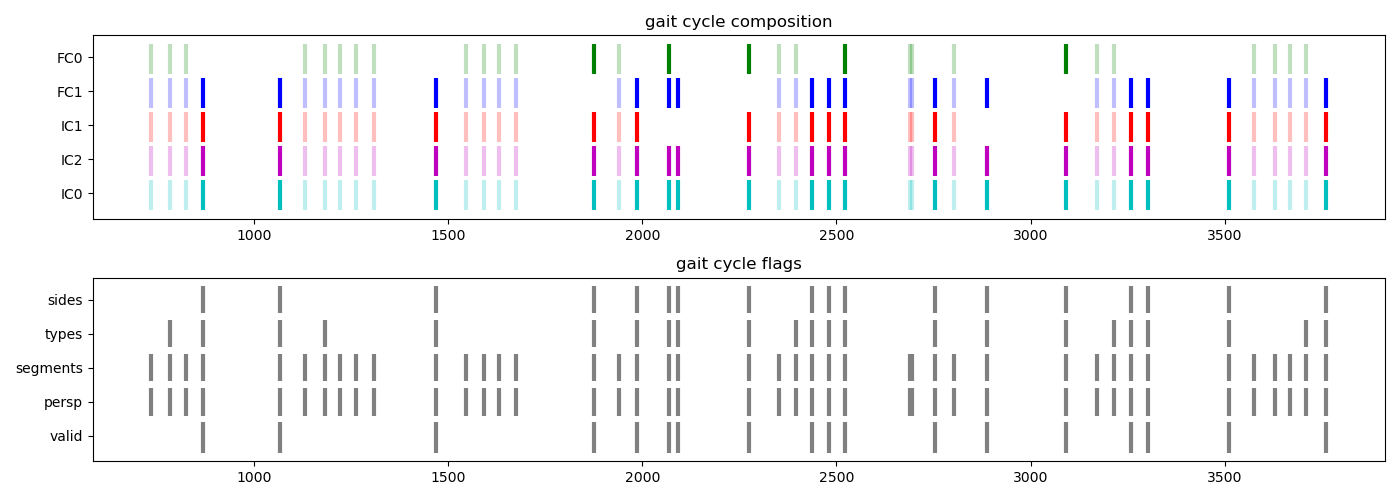

In [81]:
from matplotlib.lines import Line2D
# t = np.linspace(0, np.max(R.keypoints.shape) / R.fps, np.max(R.keypoints.shape))
t = np.linspace(0, np.max(R.keypoints.shape), np.max(R.keypoints.shape))
valid_gcs = [gc for gc in R.gait_cycles if gc.flags.valid==True]


plt.close("all")
fig, axs = plt.subplots(2, 1, figsize=(14, 5))

for gc in R.gait_cycles:
    alpha = 1 if gc.flags.valid else 0.25
    if gc.IC0 != None:
        axs[0].vlines(gc.IC0.frame,0,0.9,'c', linewidth=3, alpha=alpha)
    if gc.IC2 != None:
        axs[0].vlines(gc.IC0.frame,1,1.9,'m', linewidth=3, alpha=alpha)
    if gc.IC1 != None:
        axs[0].vlines(gc.IC0.frame,2,2.9,'r', linewidth=3, alpha=alpha)
    if gc.FC1 != None:
        axs[0].vlines(gc.IC0.frame,3,3.9,'b', linewidth=3, alpha=alpha)
    if gc.FC0 != None:
        axs[0].vlines(gc.IC0.frame,4,4.9,'g', linewidth=3, alpha=alpha)

axs[0].set_yticks([0.5,1.5,2.5,3.5,4.5],['IC0','IC2','IC1','FC1','FC0'])
# axs[0].grid()
axs[0].set_title('gait cycle composition')

for gc in R.gait_cycles:
    if gc.flags.valid:
        axs[1].vlines(gc.IC0.frame,0,0.9,'gray', linewidth=3)
    if gc.flags.perspectives_ok:
        axs[1].vlines(gc.IC0.frame,1.1,1.9,'gray', linewidth=3)
    if gc.flags.segments_ok:
        axs[1].vlines(gc.IC0.frame,2.1,2.9,'gray', linewidth=3)
    if gc.flags.types_ok:
        axs[1].vlines(gc.IC0.frame,3.1,3.9,'gray', linewidth=3)
    if gc.flags.sides_ok:
        axs[1].vlines(gc.IC0.frame,4.1,4.9,'gray', linewidth=3)
    
axs[1].set_yticks([0.5,1.5,2.5,3.5,4.5],['valid','persp','segments','types','sides'])
# axs[1].grid()
axs[1].set_title('gait cycle flags')

plt.tight_layout()
plt.show()

In [ ]:
np.array([[gc.IC0.frame, len(gc.gait_events), gc.IC1!=None, gc.FC0!=None, gc.FC1 != None] for gc in R.gait_cycles if gc.valid])

In [ ]:
for gc in R.gait_cycles:
    gc.print()

In [ ]:
# GE detection & false positive rejection
fig, axs = plt.subplots(4,1,figsize=(15,4))

side = 'left'

heel_thr = R.heel_thr * 1
ankle_thr = R.heel_thr * 1
big_toe_thr = R.toe_thr * 1

heel = R.keypoints[R.labels.index(f"{side}_heel"), :, :]
big_toe = R.keypoints[R.labels.index(f"{side}_big_toe"), :, :]
ankle = R.keypoints[R.labels.index(f"{side}_ankle"), :, :]

heel_vel = np.linalg.norm(np.diff(heel, axis=1), axis=0) * R.fps
ankle_vel = np.linalg.norm(np.diff(ankle, axis=1), axis=0) * R.fps
big_toe_vel = np.linalg.norm(np.diff(big_toe, axis=1), axis=0) * R.fps

ground_contact = (
    (heel_vel < heel_thr) | (ankle_vel < ankle_thr) | (big_toe_vel < big_toe_thr)
).astype(int)
axs[0].plot(ground_contact)
axs[0].plot(R.turn_mask)


# ground_contact[self.turn_mask] = 0
# ground_contact = np.where(self.turn_mask[1:]=='turn',ground_contact,0)

contact_diff1 = np.diff(
    np.pad(ground_contact, 1, "constant")
)  # NOTE:pad beginning and end of array with 0 for diff

# remove too short contact periods
starts = np.nonzero(contact_diff1 == 1)[0]
ends = np.nonzero(contact_diff1 == -1)[0]
for start, end in zip(starts, ends):
    if end - start < R.min_stance_time:
        ground_contact[start:end] = 0
axs[1].plot(ground_contact)

# remove too short swing periods
contact_diff2 = np.diff(np.pad(ground_contact, 1, "constant"))
starts = np.nonzero(contact_diff2 == 1)[0]
ends = np.nonzero(contact_diff2 == -1)[0]
for start, end in zip(starts, ends):
    if end - start < R.min_swing_time:
        ground_contact[start:end] = 1

axs[2].plot(ground_contact)
contact_diff3 = np.diff(np.pad(ground_contact, 1, "constant"))
ICs = np.nonzero(contact_diff3 == 1)[0] + 1
FCs = np.nonzero(contact_diff3 == -1)[0] + 1


# axs[1].plot(contact_diff1)
# axs[2].plot(contact_diff2)
# axs[3].plot(contact_diff3)
plt.tight_layout()

## Custom statistics

In [ ]:
method_A_data = np.array([0,1,2,3,4])
method_B_data = np.array([5,6,4,7,9])
print(method_A_data)
print(method_B_data)

In [ ]:
icc_results = icc_statistics(method_A_data,method_B_data)
icc_results

In [ ]:
ICC_3_1 = float(icc_results.loc[icc_results["Type"]=="ICC3"]["ICC"].iloc[0])
ICC_3_1

In [ ]:
icc_results

In [ ]:
subjects = list(range(1, len(method_A_data) + 1))

# Prepare the DataFrame

data = pd.DataFrame(
    {
        "Subject_ID": subjects + subjects,  # Repeat subject IDs for each method
        "Measurement": list(method_A_data) + list(method_B_data),  # Combine measurements
        "Method": ["A"] * len(method_A_data) + ["B"] * len(method_B_data),  # Label methods
    }
)

# Convert "Method" to categorical
data["Method"] = pd.Categorical(data["Method"])
data

## Gait analysis

In [ ]:
## load STEREO data
stereo_file_path = f"stereo_videos\\validation_test\\{participant}\\43916681.npz"
loaded_stereo_data = np.load(stereo_file_path)

stereo_data = loaded_stereo_data["keypoints_3d_filtered"]
stereo_labels = list(loaded_stereo_data["kpt_labels"])

print(f"stereo data: {stereo_data.shape}")
print(f"stereo_labels: {len(stereo_labels)}")
for prop, val in stereo_properties.items():
    
    print(f"{prop:<13} {val:.2f}")

print("\n \n")

# load QUALISYS data
qualisys_file_path = f"stereo_videos\\validation_test\\{participant}\\qualisys.npz"
loaded_qualisys_data = np.load(qualisys_file_path, allow_pickle=True)
# convert values to meters
qualisys_data = loaded_qualisys_data["keypoints"]
qualisys_labels = loaded_qualisys_data["kpt_labels"].tolist()

# filter data
qualisys_data = filter_data(
    qualisys_data,
    qualisys_properties["fps"],
    "lowpass",
    [qualisys_properties["filter_cutoff"]],
    qualisys_properties["filter_order"],
    qualisys_properties["max_gap"],
)

print(f"qualisys_data: {qualisys_data.shape}")
print(f"qualisys_labels: {len(qualisys_labels)}")
for prop, val in qualisys_properties.items():
    print(f"{prop:<13} {val:.2f}")

### Step detection

In [ ]:
qualisys_events_test = get_gait_events(
    keypoint_data=qualisys_data,
    kpt_labels=qualisys_labels,
    gait_analysis_properties=qualisys_properties
)
print(f"ICs: {len(qualisys_events_test['IC'])}")
print(f"FCs: {len(qualisys_events_test['FC'])}")

In [ ]:
qualisys_events_test

In [ ]:
stereo_events_test = get_gait_events(
    keypoint_data=stereo_data,
    kpt_labels=stereo_labels,
    gait_analysis_properties=stereo_properties
)
print(f"ICs: {len(stereo_events_test['IC'])}")
print(f"FCs: {len(stereo_events_test['FC'])}")

In [ ]:
stereo_events_test

In [ ]:
gait_analysis_properties = stereo_properties
gait_events = stereo_events_test
keypoint_data = stereo_data
kpt_labels = stereo_labels

# static properties for calculations
fps = gait_analysis_properties["fps"]
stride_min = gait_analysis_properties["stride_min"]
stride_max = gait_analysis_properties["stride_max"]

perspectives = ["all", "front_straight", "back_straight"]
# metrics of interest (for each side)
moi = {
    metric: []
    for metric in [
        "step_time",
        "step_length",
        "stride_time",
        "stride_length",
        "stride_velocity",
        "swing_time",
        "double_support_time",
        "base_of_support",
    ]
}
# output data structure
metrics = {
    perspective: {
        "left": copy.deepcopy(moi),
        "right": copy.deepcopy(moi),
    }
    for perspective in perspectives
}

# Initial- and Final-contact gait events
ICs = gait_events["IC"]
FCs = gait_events["FC"]

num_steps_used = 0
num_steps_discarded = 0

accepted_ICs = []
rejected_no_full_cycle = []
rejected_bad_stride_time = []
rejected_bad_perspective = []
rejected_missing_GEs = []

GE_log = []
GE_log.append(f"i, IC0, ipsi, perspective, IC0, FC0, IC1, FC1, IC2")

# iterate Initial Contact gait events
for i, IC in enumerate(ICs):

    # ipsilateral and contralateral sides for current gait event
    ipsi = IC["side"]
    contra = "left" if ipsi == "right" else "right"
    
    # frame idx of curernt IC
    IC0 = IC["frame"]


    # perspective value ('straight_front'/'straight_back') or 'all' if missing
    perspective = IC.get("perspective", "all")

    if perspective not in perspectives:
        rejected_bad_perspective.append(IC0)
        continue

    # get the next ipsilateral event's global index (relative to the whole event list), return None otherwise
    same_foot_next_idx = next(
        (j for j, event in enumerate(ICs[i + 1 :], start=i + 1) if event["side"] == ipsi and event["perspective"]==perspective), None
    )
    # check if there is a next ispi IC (full gait cycle for current foot)
    if same_foot_next_idx is not None:

        # stride time = time elapsed between heelstrikes of the same foot
        stride_time = (ICs[same_foot_next_idx]["frame"] - IC0) / fps

        # stride time falls in realistic time range
        if stride_min <= stride_time <= stride_max:
            # frame index of next IC event (ipsilateral)
            IC2 = ICs[same_foot_next_idx]["frame"]

            # frame index of first contralateral heel strike (between current and next ipsilateral)
            tolerance = fps*0.2
            IC1 = get_frame_indices(ICs, contra, IC0, IC2, tolerance=tolerance)

            FC0, FC1 = None, None

            # if there's a next contralateral GE
            if IC1:
                IC1 = IC1[0]

                # see gait_events.png
                FC0 = get_frame_indices(FCs, contra, IC0, IC1, tolerance=tolerance)
                FC1 = get_frame_indices(FCs, ipsi, IC1, IC2, tolerance=tolerance)                

                FC0 = FC0[0] if FC0 else None
                FC1 = FC1[0] if FC1 else None

                # print(i, IC['frame'], ipsi, perspective, IC0, FC0, IC1, FC1, IC2)
                GE_log.append(f"{i}, {IC0}, {ipsi}, {perspective}, {IC0}, {FC0}, {IC1}, {FC1}, {IC2}")
            # if either of the values is None, skip cycle
            if any(x is None for x in [IC0, IC1, IC2, FC0, FC1]):
                rejected_missing_GEs.append(IC0)
                continue
            

            # TODO: fix this shit
#------------------------------------------------------------------------------------------------------------------------------
            accepted_ICs.append(IC0)

            IC0_heel_position = stereo_data[stereo_labels.index(f"{ipsi}_heel"), :,IC0]
            IC1_heel_position = stereo_data[stereo_labels.index(f"{contra}_heel"), :,IC1]
            IC2_heel_position = stereo_data[stereo_labels.index(f"{ipsi}_heel"), :,IC2]


            #step time [sec] = ipsi IC -> contra IC, IC1-IC0
            step_time = (IC1-IC0)/fps
       
            #swing time [sec] = ipsi FC -> next ispi IC, IC2-FC1
            swing_time = (IC2-FC1)/fps

            # step length [m] = ipsi IC-> contra IC, IC1-IC0
            step_length = np.linalg.norm(IC1_heel_position-IC0_heel_position)

            #stride lenght [m] = ipsi IC -> ipsi IC, IC2-IC0
            stride_length = np.linalg.norm(IC2_heel_position-IC0_heel_position)

            #stride velocity [m/s] = stide lenght / stride time
            stride_velocity = stride_length / stride_time
            
            #double support time [sec]= (ipsi IC-> contra FC) + (conrta IC->ispi FC), (FC0-IC0)+(FC1-IC1)
            double_support_time = ((FC0-IC0)+(FC1-IC1))/fps

            #base of support [m] = tbd
            # norm(np.cross(p2-p1, p1-p3))/norm(p2-p1)
            # line connecting consecutive ispi heel positions
            IC2_IC0_line = IC2_heel_position-IC0_heel_position
            IC0_IC1_line = IC0_heel_position-IC1_heel_position

            base_of_support = np.linalg.norm(np.cross(IC2_IC0_line, IC0_IC1_line))/np.linalg.norm(IC2_IC0_line)

            num_steps_used+=1
            for pers in ["all", perspective]:
                metrics[pers][ipsi]["step_time"].append(step_time)
                metrics[pers][ipsi]["step_length"].append(step_length)
                metrics[pers][ipsi]["stride_time"].append(stride_time)
                metrics[pers][ipsi]["stride_length"].append(stride_length)
                metrics[pers][ipsi]["stride_velocity"].append(stride_velocity)
                metrics[pers][ipsi]["swing_time"].append(swing_time)
                metrics[pers][ipsi]["double_support_time"].append(double_support_time)
                metrics[pers][ipsi]["base_of_support"].append(base_of_support)
        else:
            rejected_bad_stride_time.append(IC0)

    else:
        rejected_no_full_cycle.append(IC0)
parameters = {}
for perspective, data in metrics.items():
    parameters[perspective] = {
        metric: {
            **get_mean_and_cv(data["left"][metric], data["right"][metric]),
            "asymmetry": compute_asymmetry(data["left"][metric], data["right"][metric]),
        }
        for metric in data["left"]
    }

create_debug_fig = True
if create_debug_fig:
    turn_mask, perspective = get_turns_and_perspective(
        keypoint_data=keypoint_data,
        kpt_labels=kpt_labels,
        sampling_fr=fps,
        min_peak_height=0.3,
        min_walk_duration=2
    )
    accepted_ICs = np.array(accepted_ICs)
    rejected_no_full_cycle = np.array(rejected_no_full_cycle)
    rejected_bad_stride_time = np.array(rejected_bad_stride_time)
    rejected_bad_perspective = np.array(rejected_bad_perspective)
    rejected_missing_GEs = np.array(rejected_missing_GEs)

    t = np.linspace(0, keypoint_data.shape[2], keypoint_data.shape[2])

    accepted_vis = np.zeros_like(t)
    rejected_cycle_vis = np.zeros_like(t)
    rejected_stride_vis = np.zeros_like(t)
    rejected_perspective_vis = np.zeros_like(t)
    rejected_missing_vis = np.zeros_like(t)

    rejected_cycle_vis[rejected_no_full_cycle] = 1
    rejected_stride_vis[rejected_bad_stride_time] = 1
    if rejected_bad_perspective.shape != (0,): rejected_perspective_vis[rejected_bad_perspective] = 1
    rejected_missing_vis[rejected_missing_GEs] = 1
    accepted_vis[accepted_ICs] = 1


    plt.close("all")
    fig, axs = plt.subplots(2, 1, figsize=(14, 3))
    axs[0].plot(t,rejected_missing_vis, 'r', label='missing GEs')
    axs[0].plot(t,rejected_stride_vis, 'tab:pink', label='bad stride time')
    axs[0].plot(t, rejected_cycle_vis, 'tab:brown', label='no full cycle')
    if rejected_bad_perspective.shape != (0,):axs[0].plot(t, rejected_perspective_vis,'tab:black', label='wrong perspective')
    axs[0].plot(t,accepted_vis, 'b')
    axs[0].plot(turn_mask, 'k--', alpha=0.35, label="turn mask")
    axs[1].plot(t,perspective, label="perspective")

    axs[0].set_title("GEs used/rejected during analysis")
    axs[0].legend()
    axs[1].legend()
    axs[1].set_yticks([0, 1], ["back", "front"])

    plt.tight_layout()
    plt.show()


In [ ]:
with open("./test.txt","w") as f:
    for line in GE_log:
        f.write(line+"\n")

In [ ]:
display_results(parameters)

In [ ]:
ICs.__len__()
len(accepted_ICs)

In [ ]:
for perspective, sides in metrics.items():
    print("\n"+perspective)
    for side, metrics_per_side in sides.items():
        print(side, metrics_per_side)
        for metric, metric_data in metrics_per_side.items():
            print(metric,metric_data)
    

#### Get gait-events (Brüning-Ridge velocity thr)

In [ ]:
velocity = 1
gait_analysis_properties = stereo_properties
kpt_labels = stereo_labels
keypoint_data = stereo_data
debug_fig_file_path = "./"
side = "right"

fps = gait_analysis_properties["fps"]
turn_mask, perspective = get_turns_and_perspective(
        keypoint_data=keypoint_data,
        kpt_labels=kpt_labels,
        sampling_fr=fps,
        min_peak_height=0.3,
        min_walk_duration=2
        )

heel_thr = gait_analysis_properties["heel_thr"] * velocity
# use ankle marker too (in case the other 2 are not visible, also better for stereo - no obstuction issues)
ankle_thr = gait_analysis_properties["heel_thr"] * velocity
big_toe_thr = gait_analysis_properties["toe_thr"] * velocity

# Extract trajectories
heel = keypoint_data[kpt_labels.index(f"{side}_heel"), :, :]
big_toe = keypoint_data[kpt_labels.index(f"{side}_big_toe"), :, :]
ankle = keypoint_data[kpt_labels.index(f"{side}_ankle"), :, :]

# Compute 3D velocity magnitudes
heel_vel = np.linalg.norm(np.diff(heel, axis=1), axis=0) * fps
ankle_vel = np.linalg.norm(np.diff(ankle, axis=1), axis=0) * fps
big_toe_vel = np.linalg.norm(np.diff(big_toe, axis=1), axis=0) * fps

# Ground contact detection based on thresholds
ground_contact = (
    (heel_vel < heel_thr) | (ankle_vel < ankle_thr) | (big_toe_vel < big_toe_thr)
).astype(int)

min_gc_duration = int(gait_analysis_properties["stance_min"] * fps)
min_no_gc_duration = int(gait_analysis_properties["swing_min"] * fps)

# Remove too short ground contact periods
contact_diff = np.diff(
    np.pad(ground_contact, 1, "constant")
)  # NOTE:pad beginning and end of array with 0 for diff
starts = np.nonzero(contact_diff == 1)[0]
ends = np.nonzero(contact_diff == -1)[0]

for start, end in zip(starts, ends):
    if end - start < min_gc_duration:
        ground_contact[start:end] = 0

# Remove too short swing periods
contact_diff = np.diff(np.pad(ground_contact, 1, "constant"))
starts = np.nonzero(contact_diff == 1)[0]
ends = np.nonzero(contact_diff == -1)[0]

for start, end in zip(starts, ends):
    if end - start < min_no_gc_duration:
        ground_contact[start:end] = 1

# exclude gait events of turn segments
ground_contact_diff = np.pad(np.diff(ground_contact), 1, "constant")
ground_contact_diff_straight = np.where(turn_mask, 0, ground_contact_diff)

# Identify initial contacts (ICs) and final contacts (FCs)
ICs = np.nonzero(ground_contact_diff_straight == 1)[0] + 1
FCs = np.nonzero(ground_contact_diff_straight == -1)[0] + 1

# Compute walking velocity from stride lengths and durations
# also filter false positive gait events based on them
stride_lengths = []
stride_durations = []
bad_GE_indices = []

direction = []

# refine ICs & Fcs based on stride duration and perspective
for i in range(len(ICs) - 1):
    current_IC = ICs[i]
    next_IC = ICs[i + 1]

    # temporal difference between current & next IC event
    stride_duration = (next_IC - current_IC) / fps

    # check if gait events belong to same straight segment
    facing_same_way = perspective[current_IC] == perspective[next_IC]
    stride_duration_ok = (
        gait_analysis_properties["stride_min"]
        <= stride_duration
        <= gait_analysis_properties["stride_max"]
    )

    if not stride_duration_ok and facing_same_way:
        bad_GE_indices.append(i + 1)

    if stride_duration_ok and facing_same_way:
        # take the spatial difference of heel keypoints between current & next IC event
        stride_length_heel = np.linalg.norm(heel[:, next_IC] - heel[:, current_IC])
        stride_lengths.append(stride_length_heel)

        stride_durations.append(stride_duration)
        direction.append(perspective[current_IC])

# remove false positive gait events
ICs = np.delete(ICs, bad_GE_indices)
FCs = np.delete(FCs, bad_GE_indices)

stride_lengths = np.array(stride_lengths)
stride_durations = np.array(stride_durations)

print(stride_duration.shape)
print(stride_lengths.shape)

mean_velocity = np.nanmean(stride_lengths / stride_durations)

create_debug_fig = False
if debug_fig_file_path != None:
    create_debug_fig = True

# fmt: off
if create_debug_fig:

    # basename, extension = os.path.splitext(os.path.basename(debug_fig_file_path))
    # save_folder = "debug_figs"
    # filename = os.path.join(save_folder, f"{basename}_gait_events_{side}")
    filename = f"{os.path.splitext(debug_fig_file_path)[0]}_{side}"

    # create array to visualize gait events after filtering out bad ones
    gait_event_vis = np.zeros_like(ground_contact_diff_straight)
    gait_event_vis[ICs] = 1
    gait_event_vis[FCs] = -1
    tS = np.linspace(0, len(ankle_vel) / fps, len(ankle_vel))

    plt.close("all")
    fig, axs = plt.subplots(5, 1, figsize=(14, 9))

    axs[0].plot(tS, ankle_vel, label="velocity")
    axs[0].plot(tS, ground_contact * ankle_thr, label="ground contact at thr")

    axs[1].plot(tS, big_toe_vel, label="velocity")
    axs[1].plot(tS, ground_contact * big_toe_thr, label="ground contact at thr")

    axs[2].plot(tS, heel_vel, label="velocity")
    axs[2].plot(tS, ground_contact * heel_thr, label="ground contact at thr")

    axs[3].plot(tS, ground_contact_diff[1:], alpha=0.4, label="ground contact diff")
    axs[3].plot(tS[1:], turn_mask[2:], "r--", label="turn mask")
    axs[3].plot(tS, gait_event_vis[1:], "b", alpha=1, label="gc diff straight")
    axs[3].plot(tS, ground_contact_diff_straight[1:], "r", alpha=0.4, label="removed GEs")

    axs[4].plot(tS, perspective[1:], label="perspective")

    axs[0].set_title("ankle velocity")
    axs[1].set_title("toe velocity")
    axs[2].set_title("heel velocity")
    axs[3].set_title("ground contact diff (gait events)")
    axs[0].set_yticks([0, 3, ankle_thr])
    axs[1].set_yticks([0, 3, big_toe_thr])
    axs[2].set_yticks([0, 3, heel_thr])
    axs[3].set_yticks([-1,1,],["FC", "IC"],)
    axs[3].set_yticks([-1,1,],["FC", "IC"],)
    axs[4].set_yticks([0, 1], ["back", "front"])

    for ax in axs:
        ax.legend(loc="upper left")
        ax.grid()

    plt.tight_layout()
    plt.savefig(filename)
    plt.close("all")
    print(f"figure saved to: \n{filename}")

#### Get gait event (peaks)

In [ ]:
velocity = 1
side = "right"
# side = "left"


stereo_turn_mask, stereo_perspective = get_turns_and_perspective(
    stereo_data,
    stereo_labels,
    stereo_properties["fps"],
    min_peak_height=0.3,
    relative_height=0.85,
    min_walk_duration=2,
)
qualisys_turn_mask, qualisys_perspective = get_turns_and_perspective(
    qualisys_data,
    qualisys_labels,
    qualisys_properties["fps"],
    min_peak_height=0.3,
    relative_height=0.85,
    min_walk_duration=2,
)
##------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Extract trajectories
shift = 250
stereo_turn_mask = stereo_turn_mask[shift:]
stereo_perspective = stereo_perspective[shift:]
stereo_heel =  stereo_data[stereo_labels.index(f"{side}_heel"), :, shift:]
stereo_toe = stereo_data[stereo_labels.index(f"{side}_big_toe"), :, shift:]
stereo_ankle = stereo_data[stereo_labels.index(f"{side}_ankle"), :, shift:]

qualisys_heel = qualisys_data[qualisys_labels.index(f"{side}_heel"), :, :]
qualisys_toe = qualisys_data[qualisys_labels.index(f"{side}_big_toe"), :, :]
qualisys_ankle = qualisys_data[qualisys_labels.index(f"{side}_ankle"), :, :]


# Compute 3D velocity magnitudes, apply turn masks
stereo_heel_vel = np.where(stereo_turn_mask[1:],0,np.linalg.norm(np.diff(stereo_heel, axis=1), axis=0) * stereo_properties["fps"])
stereo_ankle_vel = np.where(stereo_turn_mask[1:],0,np.linalg.norm(np.diff(stereo_ankle, axis=1), axis=0) * stereo_properties["fps"])
stereo_toe_vel = np.where(stereo_turn_mask[1:],0,np.linalg.norm(np.diff(stereo_toe, axis=1), axis=0) * stereo_properties["fps"])

qualisys_heel_vel = np.where(qualisys_turn_mask[1:],0, np.linalg.norm(np.diff(qualisys_heel, axis=1), axis=0) * qualisys_properties["fps"])
qualisys_ankle_vel = np.where(qualisys_turn_mask[1:],0,np.linalg.norm(np.diff(qualisys_ankle, axis=1), axis=0) * qualisys_properties["fps"])
qualisys_toe_vel = np.where(qualisys_turn_mask[1:],0,np.linalg.norm(np.diff(qualisys_toe, axis=1), axis=0) * qualisys_properties["fps"])


# find peaks, left & right bases 
stereo_min_peak_distance = 0.75 * stereo_properties["fps"]
qualisys_min_peak_distance = 0.75 * qualisys_properties["fps"]

velocity_profiles = [stereo_ankle_vel,qualisys_ankle_vel,stereo_heel_vel,qualisys_heel_vel ,stereo_toe_vel,qualisys_toe_vel]
all_peaks=[]
all_peak_properties=[]
all_left_bases, all_right_bases, all_width_heights = [],[],[]

rel_height = 0.75

for ind, velocity_profile in enumerate(velocity_profiles):
    if ind%2==0:
        min_peak_distance = stereo_min_peak_distance
    else:
        min_peak_distance = qualisys_min_peak_distance

    peaks, peak_properties = find_peaks(velocity_profile, height=[0.75,4], distance=min_peak_distance)
    widths, width_heights, left_ips, right_ips = peak_widths(x=velocity_profile, peaks=peaks, rel_height=rel_height)

    all_peaks.append(peaks)
    all_left_bases.append(left_ips)
    all_right_bases.append(right_ips)
    all_width_heights.append(width_heights)


##------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PLOT
if True:
    tS = np.linspace(0, len(stereo_ankle_vel) / 60, len(stereo_ankle_vel))
    tQ = np.linspace(0, len(qualisys_ankle_vel) / 100, len(qualisys_ankle_vel))
    xticks = np.array(
        [0, 11, 16, 18, 23, 25, 29, 31, 36, 38, 43, 45, 50, 52, 57, 59, 64, 66]
    )  # manual annotation

    plt.close("all")
    num_plots = 6
    fig, axs = plt.subplots(6, 1, figsize=(14, num_plots * 1.2))

    axs[0].set_title("ankle velocity")
    axs[0].plot(tS, stereo_ankle_vel, label="stereo")
    axs[1].plot(tQ, qualisys_ankle_vel, label="qualisys")

    axs[2].set_title("heel velocity")
    axs[2].plot(tS, stereo_heel_vel, "c", label="stereo")
    axs[3].plot(tQ, qualisys_heel_vel, "c", label="qualisys")

    axs[4].set_title("toe velocity")
    axs[4].plot(tS, stereo_toe_vel, "g", label="stereo")
    axs[5].plot(tQ, qualisys_toe_vel, "g", label="qualisys")


    for ind, ax in enumerate(axs):
        # plot turn masks
        if ind % 2 == 1:
            ax.plot(tQ[1:], qualisys_turn_mask[2:] * 5, "k--", label="turn mask", alpha=0.5)
            fs = qualisys_properties["fps"]
        else:
            ax.plot(tS[1:], stereo_turn_mask[2:] * 5, "k--", label="turn mask", alpha=0.5)
            fs = stereo_properties["fps"]
        #plot peaks, bases
        ax.plot(all_peaks[ind]/fs,velocity_profiles[ind][all_peaks[ind]],"r*", alpha=0.65)
        ax.plot(all_left_bases[ind]/fs,all_width_heights[ind],"o",c="orange",label="FC", markersize=4)
        ax.plot(all_right_bases[ind]/fs,all_width_heights[ind],"o",c="blue",label="IC", markersize=4)
        
        
        ax.set_ylim([0, 4])
        ax.grid()
        ax.legend(loc="upper left")
    plt.tight_layout()

In [ ]:
qualisys_ground_contact = np.ones_like(qualisys_ankle_vel)
ankle_bases = np.round(np.array([all_left_bases[1], all_right_bases[1]]).T).astype(int)
heel_bases = np.round(np.array([all_left_bases[3],all_right_bases[3]]).T).astype(int)
toe_bases = np.round(np.array([all_left_bases[5], all_right_bases[5]]).T).astype(int)

for (ankle_lb, ankle_rb), (heel_lb, heel_rb), (toe_lb, toe_rb) in zip(ankle_bases, heel_bases, toe_bases):
    qualisys_ground_contact[ankle_lb:ankle_rb] = 0
    qualisys_ground_contact[heel_lb:heel_rb] = 0
    qualisys_ground_contact[toe_lb:toe_rb] = 0

stereo_ground_contact = np.ones_like(stereo_ankle_vel)
ankle_bases = np.round(np.array([all_left_bases[0], all_right_bases[0]]).T).astype(int)
heel_bases = np.round(np.array([all_left_bases[2],all_right_bases[2]]).T).astype(int)
toe_bases = np.round(np.array([all_left_bases[4], all_right_bases[4]]).T).astype(int)

for (ankle_lb, ankle_rb), (heel_lb, heel_rb), (toe_lb, toe_rb) in zip(ankle_bases, heel_bases, toe_bases):
    stereo_ground_contact[ankle_lb:ankle_rb] = 0
    stereo_ground_contact[heel_lb:heel_rb] = 0
    stereo_ground_contact[toe_lb:toe_rb] = 0



plt.close('all')
plt.figure(figsize=(14,1.5))
plt.plot(tQ,qualisys_ground_contact, label= "qualisys")
plt.plot(tS, stereo_ground_contact, label="stereo", alpha=0.5)
plt.tight_layout()

In [ ]:
def get_gait_events_one_side_peaks(
    data: np.ndarray,
    kpt_labels: list,
    side: Literal["left", "right"],
    gait_analysis_properties: dict,
    velocity: float,
    turn_mask: np.ndarray,
    perspective: np.ndarray,
    create_debug_figure: bool = False,
    file_path: str = "",):
    """
    Identifies Gait Events (GE) by finding peaks in the velocity profiles of markers on the foot (heel, toe, ankle).
    Also calculates the velocity profile to iteratively update GEs (2 stage).

    Args:
        data: interpolated and filtered keypoint data (keypoints x dims x frames)
        velocity: initial walking velocity estimate (m/s)
        side: 'left' or 'right'
        kpt_labels: list of keypoint labels corresponding to data (left_ankle, nose, etc)
        gait_analysis_properties: dictionary of static parameters from gait_analysis_properties.json

    Returns:
        ICs: list of Initial Contact (IC) frame indices
        FCs: list of Final Contact (FC) frame indices
        velocity: computed walking velocity (m/s)
    """
    fps = gait_analysis_properties["fps"]

In [ ]:
data = stereo_data
kpt_labels = stereo_labels
fps = stereo_properties["fps"]
create_debug_fig = True

turn_mask, perspective = get_turns_and_perspective(
        data,
        kpt_labels,
        fps,
        min_peak_height=0.3,
        relative_height=0.85,
        min_walk_duration=2,
    )

heel = data[kpt_labels.index(f"{side}_heel"), :, :]
ankle = data[kpt_labels.index(f"{side}_ankle"), :, :]
toe = data[kpt_labels.index(f"{side}_big_toe"), :, :]


heel_vel = np.where(turn_mask[1:],0, np.linalg.norm(np.diff(heel, axis=1), axis=0) * fps)
ankle_vel = np.where(turn_mask[1:],0,np.linalg.norm(np.diff(ankle, axis=1), axis=0) * fps)
toe_vel = np.where(turn_mask[1:],0,np.linalg.norm(np.diff(toe, axis=1), axis=0) * fps)

min_peak_distance = 0.75 * fps
rel_height = 0.75

heel_peaks, heel_peak_properties = find_peaks(heel_vel, height=[0.75,4], distance=min_peak_distance)
heel_widths, heel_width_heights, heel_left_ips, heel_right_ips = peak_widths(x=heel_vel, peaks=heel_peaks, rel_height=rel_height)

ankle_peaks, ankle_peak_properties = find_peaks(ankle_vel, height=[0.75,4], distance=min_peak_distance)
ankle_widths, ankle_width_heights, ankle_left_ips, ankle_right_ips = peak_widths(x=ankle_vel, peaks=ankle_peaks, rel_height=rel_height)

toe_peaks, toe_peak_properties = find_peaks(toe_vel, height=[0.75,4], distance=min_peak_distance)
toe_widths, toe_width_heights, toe_left_ips, toe_right_ips = peak_widths(x=toe_vel, peaks=toe_peaks, rel_height=rel_height)

ground_contact = np.ones_like(ankle_vel)

heel_bases = np.array([heel_left_ips.round().astype(int), heel_right_ips.round().astype(int)]).T
ankle_bases = np.array([ankle_left_ips.round().astype(int), ankle_right_ips.round().astype(int)]).T
toe_bases = np.array([toe_left_ips.round().astype(int), toe_right_ips.round().astype(int)]).T

# Remove too short ground contact periods
min_gc_duration = int(stereo_properties["stance_min"] * fps)
min_no_gc_duration = int(stereo_properties["swing_min"] * fps)


# TODO: itt tartok
for (ankle_lb, ankle_rb), (heel_lb, heel_rb), (toe_lb, toe_rb) in zip(ankle_bases, heel_bases, toe_bases):
    if (ankle_rb-ankle_lb)/fps > min_gc_duration:
        ground_contact[ankle_lb:ankle_rb] = 0

    if (heel_rb-heel_lb)/fps < min_gc_duration:
        ground_contact[heel_lb:heel_rb] = 0

    if (toe_rb-toe_lb)/fps < min_gc_duration:
        ground_contact[toe_lb:toe_rb] = 0

# # Remove too short ground contact periods
# min_gc_duration = int(stereo_properties["stance_min"] * fps)
# min_no_gc_duration = int(stereo_properties["swing_min"] * fps)

# contact_diff = np.diff(
#     np.pad(ground_contact, 1, "constant")
# )  # NOTE:pad beginning and end of array with 0 for diff
# starts = np.nonzero(contact_diff == 1)[0]
# ends = np.nonzero(contact_diff == -1)[0]

# for start, end in zip(starts, ends):
#     if end - start < min_gc_duration:
#         ground_contact[start:end] = 0

# # Remove too short swing periods
# contact_diff = np.diff(np.pad(ground_contact, 1, "constant"))
# starts = np.nonzero(contact_diff == 1)[0]
# ends = np.nonzero(contact_diff == -1)[0]

# for start, end in zip(starts, ends):
#     if end - start < min_no_gc_duration:
#         ground_contact[start:end] = 1

# # exclude gait events of turn segments
# ground_contact_diff = np.pad(np.diff(ground_contact), 1, "constant")
# ground_contact_diff_straight = np.where(turn_mask, 0, ground_contact_diff)

# # Identify initial contacts (ICs) and final contacts (FCs)
# ICs = np.nonzero(ground_contact_diff_straight == 1)[0] + 1
# FCs = np.nonzero(ground_contact_diff_straight == -1)[0] + 1

# # Compute walking velocity from stride lengths and durations
# # also filter false positive gait events based on them
# stride_lengths = []
# stride_durations = []
# bad_GE_indices = []

# direction = []

# # refine ICs & Fcs based on stride duration and perspective
# for i in range(len(ICs) - 1):
#     current_IC = ICs[i]
#     next_IC = ICs[i + 1]

#     # temporal difference between current & next IC event
#     stride_duration = (next_IC - current_IC) / fs

#     # check if gait events belong to same straight segment
#     facing_same_way = perspective[current_IC] == perspective[next_IC]
#     stride_duration_ok = (
#         stereo_properties["stride_min"]
#         <= stride_duration
#         <= stereo_properties["stride_max"]
#     )

#     if not stride_duration_ok and facing_same_way:
#         bad_GE_indices.append(i + 1)

#     # TODO: decide which kpt is best (heel or ankle or mix?)
#     if stride_duration_ok and facing_same_way:
#         # take the spatial difference of [KEYPOINT] between current & next IC event
#         #
#         stride_length_heel = np.linalg.norm(heel[:, next_IC] - heel[:, current_IC])
#         # stride_length_ankle = np.linalg.norm(ankle[:, next_IC] - ankle[:, current_IC])
#         # stride_length_toe = np.linalg.norm(big_toe[:, next_IC] - big_toe[:, current_IC])

#         # stride_lengths.append(np.array([stride_length_heel, stride_length_ankle, stride_length_toe]))
#         stride_lengths.append(stride_length_heel)
#         # stride_lengths.append(stride_length_ankle)
#         stride_durations.append(stride_duration)
#         direction.append(perspective[current_IC])

# # remove false positive gait events
# ICs = np.delete(ICs, bad_GE_indices)
# FCs = np.delete(FCs, bad_GE_indices)

# stride_lengths = np.array(stride_lengths)
# stride_durations = np.array(stride_durations)

# mean_velocity = np.nanmean(stride_lengths / stride_durations)

if create_debug_fig:
    t = np.linspace(0, len(ankle_vel) / fps, len(ankle_vel))
    plt.close("all")
    fig, axs = plt.subplots(4, 1, figsize=(14, 5))
    fig.suptitle(f"{side} side")

    axs[0].set_title("ankle velocity")
    axs[0].plot(t, ankle_vel, label="stereo")
    axs[0].plot(ankle_peaks/fps,ankle_vel[ankle_peaks],"r*", alpha=0.3)
    axs[0].plot(ankle_bases[:,0]/fps,ankle_width_heights,"o",c="orange",label="FC", markersize=4)
    axs[0].plot(ankle_bases[:,1]/fps,ankle_width_heights,"o",c="blue",label="IC", markersize=4)
    
    axs[1].set_title("heel velocity")
    axs[1].plot(t, heel_vel, "c", label="stereo")
    axs[1].plot(heel_peaks/fps,heel_vel[heel_peaks],"r*", alpha=0.3)
    axs[1].plot(heel_bases[:,0]/fps,heel_width_heights,"o",c="orange",label="FC", markersize=4)
    axs[1].plot(heel_bases[:,1]/fps,heel_width_heights,"o",c="blue",label="IC", markersize=4)
    
    axs[2].set_title("toe velocity")
    axs[2].plot(t, toe_vel, "g", label="stereo")
    axs[2].plot(toe_peaks/fps,toe_vel[toe_peaks],"r*", alpha=0.3)
    axs[2].plot(toe_bases[:,0]/fps,toe_width_heights,"o",c="orange",label="FC", markersize=4)
    axs[2].plot(toe_bases[:,1]/fps,toe_width_heights,"o",c="blue",label="IC", markersize=4)

    axs[3].plot(t, ground_contact)

    for ax in axs:
        ax.plot(t[1:], turn_mask[2:] * 5, "k--", label="turn mask", alpha=0.5)

        ax.set_ylim([0, 4])

plt.tight_layout()

In [ ]:
ankle_bases.shape

#### velocity & gait event plots

In [ ]:
# PLOTTING velocity, perspective, phase
tS = np.linspace(0, len(ankle_vel) / 60, len(ankle_vel))
xticks = np.array([0, 11, 16, 18, 23, 25, 29, 31, 36, 38, 43, 45, 50, 52, 57, 59, 64, 66])  # manual annotation

# create array to visualize gait events after filtering out bad ones
gait_event_vis = np.zeros_like(ground_contact_diff_straight)
gait_event_vis[ICs] = 1
gait_event_vis[FCs] = -1


plt.close("all")
fig, axs = plt.subplots(5, 1, figsize=(14, 9))

axs[0].plot(tS,ankle_vel,label="velocity")
axs[0].plot(tS, ground_contact*ankle_thr,label="ground contact at thr")

axs[1].plot(tS,big_toe_vel,label="velocity")
axs[1].plot(tS, ground_contact*big_toe_thr,label="ground contact at thr")

axs[2].plot(tS,heel_vel,label="velocity")
axs[2].plot(tS, ground_contact*heel_thr,label="ground contact at thr")

axs[3].plot(tS, ground_contact_diff[1:],alpha=0.4, label="ground contact diff")
axs[3].plot(tS[1:], turn_mask[2:], "r--", label="turn mask")
axs[3].plot(tS, gait_event_vis[1:],"b",alpha=1,label="gc diff straight")
axs[3].plot(tS, ground_contact_diff_straight[1:],"r",alpha=0.4,label="removed GEs")


axs[4].plot(tS, perspective[1:], label="perspective")


axs[0].set_title("ankle velocity")
axs[1].set_title("toe velocity")
axs[2].set_title("heel velocity")
axs[3].set_title("ground contact diff (gait events)")
axs[0].set_yticks([0,3,ankle_thr])
axs[1].set_yticks([0,3,big_toe_thr])
axs[2].set_yticks([0,3,heel_thr])
axs[3].set_yticks([-1,1,],["FC", "IC"])
axs[3].set_yticks([-1,1,],["FC", "IC"])
axs[4].set_yticks([0,1],["back","front"])

for ax in axs:
    # ax.set_xlim([min(xticks), max(xticks)])
    # ax.set_xticks(xticks - 3.3, xticks)
    ax.legend(loc="upper left")
    ax.grid()
    # ax.plot(tS, ground_contact*2,"m")


plt.tight_layout()

#### get all gait events (left, right)

In [ ]:
data = loaded_data["keypoints_3d_filtered"]  # stereo
kpt_labels = loaded_data["kpt_labels"].tolist()
fs = 60
gait_analysis_properties = stereo_properties

# data = qualisys_data # qualisys
# kpt_labels = qualisys_labels
# fs = 100

turn_mask, perspective = get_turns_and_perspective(data, kpt_labels,fs,2)

events = {"left": {}, "right": {}}

for side in ["left", "right"]:
    _, _, velocity = get_gait_events_one_side(data,kpt_labels,side,gait_analysis_properties,1,turn_mask,perspective,False,file_path)
    ICs, FCs, _ = get_gait_events_one_side(data,kpt_labels,side,gait_analysis_properties,velocity,turn_mask,perspective,True,file_path)
    events[side]["ICs"] = ICs
    events[side]["FCs"] = FCs


segments = []
for persp, turn in zip(perspective,turn_mask):
    match persp, turn:
        # front, straight
        case np.True_, np.False_:
            segment_name = "front_straight"
        # back, straight
        case np.False_, np.False_:
            segment_name = "back_straight"
        # all turns
        case _,_:
            segment_name = "turn"
    
    segments.append(segment_name)


IC_events = [
    {"frame": frame, "side": side, "perspective": segments[frame]}
    for side in ["left", "right"]
    for frame in events[side]["ICs"]
]
FC_events = [
    {"frame": frame, "side": side, "perspective": segments[frame]}
    for side in ["left", "right"]
    for frame in events[side]["FCs"]
]
gait_events = {"IC": IC_events, "FC": FC_events}
print(len(IC_events), len(FC_events))

## PLY

In [ ]:
import open3d as o3d

In [ ]:
print(f"keypoints_3d shape: {keypoints_3d.shape} (kpt * dims * frames)")
print(f"color shape:        {color.shape} (frames * kpt * rgb)")

In [ ]:
keypoints_3d_one_frame = keypoints_3d[:,:,0] #(kpt * dims * frames)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(keypoints_3d_one_frame)
pcd.colors = o3d.utility.Vector3dVector(color[0,:,:]/255.0)
o3d.io.write_point_cloud("./data.ply", pcd, write_ascii=True)
o3d.visualization.draw_geometries([pcd])


## 3D angular change segmentation

In [ ]:
def compute_angle(vector: np.ndarray) -> np.ndarray:
    """
    Computes the angles (in degrees) between a vector's current and previous position.
    Args:
        vector: n-dim input vector
    Returns:
        angles: angle of rotation between vector[i] and vector[i+1] in degrees.

    """
    angles = []
    for frame_idx, current_vector in enumerate(vector):
        if frame_idx < vector.shape[0] - 1:
            next_vector = vector[frame_idx + 1]
            angle = np.rad2deg(np.arccos(np.clip(np.dot(next_vector, current_vector), -1.0, 1.0)))
            angles.append(angle)
        # print(frame_idx,angle, current_vector)

    return np.array(angles)

In [ ]:
# data = stereo_data
# fps = stereo_properties["fps"]
# kpt_labels = stereo_labels

data = qualisys_data
fps = qualisys_properties["fps"]
kpt_labels = qualisys_labels

# get the y coord of shoulders (for qualisys x-y plane is horizontal, y coord was forwards/backwards movement)
# TODO: make this 3D, independent from the ground plane
shoulder_R = data[kpt_labels.index("right_shoulder"), :, :]
shoulder_L = data[kpt_labels.index("left_shoulder"), :, :]

shoulder_L_unit = (shoulder_L / np.linalg.norm(shoulder_L, axis=0))
shoulder_R_unit = (shoulder_R / np.linalg.norm(shoulder_R, axis=0))

shoulder_diff = (shoulder_R_unit-shoulder_L_unit)

t = np.arange(0, shoulder_diff.shape[1]) / fps

plt.close('all')
fig, axs = plt.subplots(4,1,figsize=(14,5))
axs[0].plot(compute_angle(shoulder_diff[0]))
axs[0].set_title("ax1 diff")

axs[1].plot(compute_angle(shoulder_diff[1]))
axs[1].set_title("ax2 diff")

axs[2].plot(compute_angle(shoulder_diff[2]))
axs[2].set_title("ax3 diff")

axs[3].plot(compute_angle(shoulder_diff.T))
axs[3].set_title("all axes")

plt.tight_layout()
plt.show()

## Spectral anal + filt

In [ ]:
keypoints_3d = loaded_data["keypoints_3d_wf"]## TODO: remname keypoints_3d_wf to keypoints_3d
Sy = keypoints_3d[stereo_idx, 2, shift:]

nans = np.isnan(Sy)

# if there are nans, interpolate the missing values for subsequent filtering
if np.any(nans):
    valid_indices = ~nans
    Sy[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(valid_indices), Sy[valid_indices])

plt.close('all')
plt.figure(figsize=(15,2))
fft_Sy = fft(Sy)
N = len(fft_Sy)
n = np.arange(N)
freq = n / (N / 60)

PSD = fft_Sy * np.conj(fft_Sy) / N
PSD = np.array(PSD)
limit = 0.2
indices =  PSD < limit # indices 
PSDClean = PSD*indices 

# indices[0] = False

fhat = indices * fft_Sy
ffilt = np.fft.ifft(fhat)

b, a = butter(N=4, Wn=[2,3], btype="bandpass", analog=False, fs=60)
Sy_filt = filtfilt(b, a, ffilt)

plt.close('all')
fig, axs = plt.subplots(2, 1, figsize=(13, 4))
axs[0].plot(freq,PSD)
axs[0].set_xlim([0,6])
axs[0].set_ylim([0,5])
axs[0].hlines(limit,0,6, color='r', linestyles='dashed')


axs[1].plot(freq,PSDClean)
axs[1].set_xlim([0,6])

plt.show()



plt.figure(figsize=(15,4))
plt.plot(ffilt,'m')
plt.plot(Sy+.5,'b')
plt.plot(Sy_filt-.5,'r')

plt.show()

In [ ]:
indices[:10]

In [ ]:
plt.close('all')
plt.figure(figsize=(13,6))

bandpass = [0.2, 15]
# orders = [1, 4,7, 8]
# band_mins = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
band_maxs = [4,5,8,10,15,20]
values = band_maxs
for idx, value in enumerate(values,1):
    b, a = butter(6, [0.2, value], fs=60, btype="band", analog=False)
    result = filtfilt(b,a,ry)
    plt.subplot(len(values),1,idx)
    plt.plot(result, label=str(value))
    plt.hlines(0,0,len(result),'r')
    plt.legend()
    

In [ ]:
# keypoints_over_time.transpose(1,2,0).shape, 
keypoints_3d.transpose(1,2,0).shape

In [ ]:
bandpass = [0.2, 4]
b, a = butter(6, bandpass, fs=60, btype="band", analog=False)

test = []

for kpt_idx, kpt in enumerate(raw_keypoints.transpose(1,2,0)):
    # fx = filtfilt(b, a, kpt[0,:])
    # fy = filtfilt(b, a, kpt[1,:])
    sx = np.multiply(kpt[0,:], scale)
    # fy = kpt[1,:]
    fy = filtfilt(b,a,kpt[1,:])
    sfy = np.multiply(fy, scale)

    depth = keypoints_3d.transpose(1,2,0)[kpt_idx,0,:]
    # print(fx.shape, fy.shape, depth.shape)
    test.append(np.stack((depth,sx,sfy)))
test= np.array(test)
print(test.shape)
type(test)
    

In [ ]:
faszom = "stereo_videos\\validation_test\\test.npz"
with open(faszom, "w") as f:
    np.savez(faszom, raw_keypoints = raw_keypoints, keypoints_2d=keypoints_2d, keypoints_3d=keypoints_3d, kpt_labels=kpt_labels, scale=scale, test = test)

print(f"Saved 3D keypoints to {faszom}")